In [ ]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
# from yellowbrick.cluster import KElbowVisualizer

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('marketing_campaign.csv', sep="\t")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


# Data Cleaning

In [ ]:
#Information on features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [ ]:
data = df.dropna()

In [ ]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

# EDA

In [ ]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], format='%d-%m-%Y')
dates = []
for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)
#Dates of the newest and oldest recorded customer
print("The newest customer's enrollment date in the records:",max(dates))
print("The oldest customer's enrollment date in the records:",min(dates))

The newest customer's enrollment date in the records: 2014-06-29
The oldest customer's enrollment date in the records: 2012-07-30


/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/397827858.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], format='%d-%m-%Y')


Understand customer base:

In [ ]:
print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts())

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


# Feature Engineering

Next, I will be performing the following steps to engineer some new features:

1. Extract the **"Age"** of a customer by the "Year_Birth" indicating the birth year of the respective person.
2. Create a feature called **"Spent"** indicating the total amount spent by the customer in various categories.
3. Create a feature called **"Living_With"** by categorizing individuals as "Partner" if married or in a relationship and "Alone" otherwise, based on their marital status.
4. Create a feature called **"Children"** to indicate total children in a household (kids + teenagers).
5. Create a feature called **"Family_Size"**, which is calculated as 1 if living alone, 2 if living with a partner, then plus the total number of children (Kidhome + Teenhome) in the household.
6. Create a feature called **"Is_Parent"** to indicate whether a person has children. It is assigned 1 if the total number of children (Children > 0) and 0 otherwise.
7. Lastly, simplifying **"Education"** into three categories: "Undergraduate" (for Basic and 2nd Cycle), "Graduate" (for Graduation), and "Postgraduate" (for Master and PhD).
8. Drop unnecessary features.

In [ ]:
#Age of customer today
data["Age"] = 2025-data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

#Deriving living situation by marital status"Alone"
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

#Feature indicating total children living in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

#Feature for total members in the householde
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

#Segmenting education levels in three groups
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

#For clarity
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

#Dropping some of the redundant features
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)
data.head(3)

/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/1493920372.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Age"] = 2025-data["Year_Birth"]
/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/1493920372.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]
/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/149

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,Graduate,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,68,1617,Alone,0,1,0
1,Graduate,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,71,27,Alone,2,3,1
2,Graduate,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,60,776,Partner,0,2,0


In [ ]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,2.323556,4.085289,2.671029,5.800993,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,0.150271,56.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,1.923716,2.740951,2.926734,3.250785,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.357417,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,132.000000,2525.000000,3.000000,5.000000,1.000000


While we noticed that the max-age is 132 years, it may due to the way we used to calculate age (i.e. 2025) and the data is old.

We will plot some of the selected features to gain more insights.

### Age

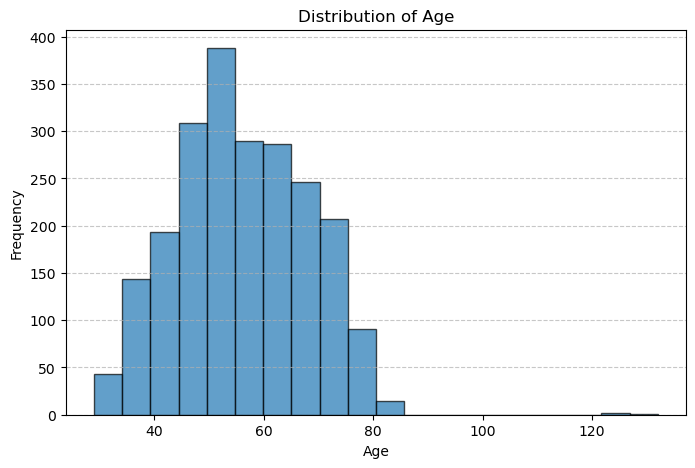

In [ ]:
# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(data['Age'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Drop outliers for age (<90)
data = data[(data["Age"]<90)]

The age distribution follows a normal pattern with a mean of approximately 50. It’s important to note that age was calculated using the year 2025, which may not accurately reflect the actual ages at the time the data was collected, as the exact collection date is unknown. However, this approximation remains useful for understanding the overall distribution of our customer base.

### Income

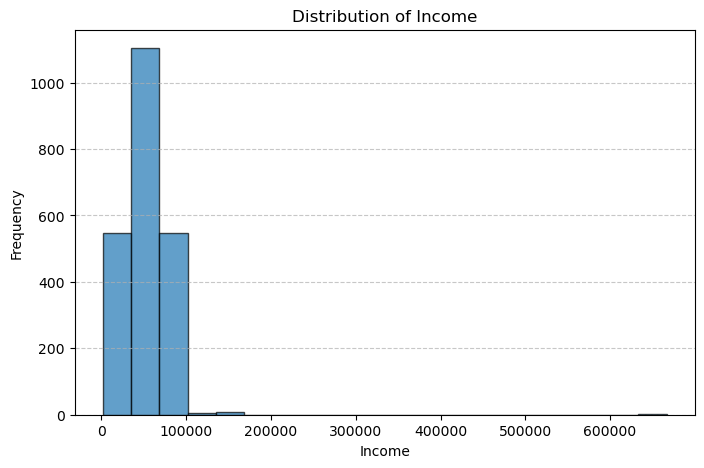

In [ ]:
# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(data['Income'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Distribution of Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Drop outliers for income (<600000)
data = data[(data["Income"]<600000)]

### Is_Parent

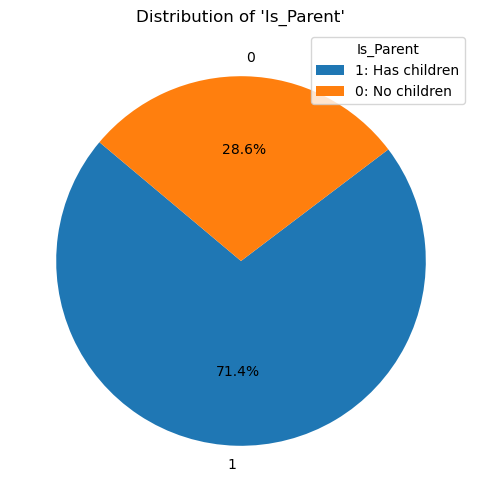

In [ ]:
# Count the occurrences of each category in 'Is_Parent'
parent_counts = data['Is_Parent'].value_counts()

# Create a pie chart
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    parent_counts, labels=parent_counts.index, autopct='%1.1f%%', startangle=140
)

# Add a legend with explanation
plt.legend(
    wedges,
    ["1: Has children", "0: No children"],
    title="Is_Parent",
    loc="best"
)

plt.title("Distribution of 'Is_Parent'")
plt.show()

### Living_With

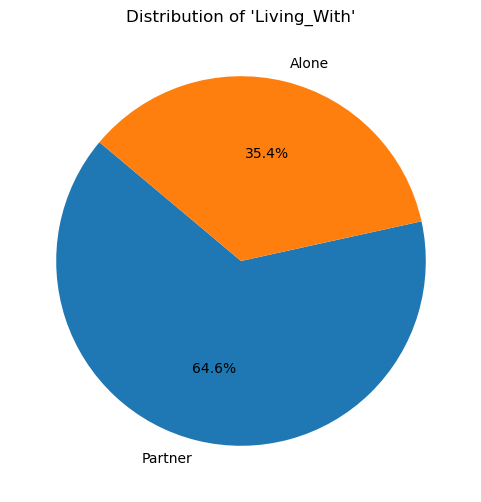

In [ ]:
# Count the occurrences of each category in 'Is_Parent'
liv_with_counts = data['Living_With'].value_counts()

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(liv_with_counts, labels=liv_with_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of 'Living_With'")
plt.show()

### Response

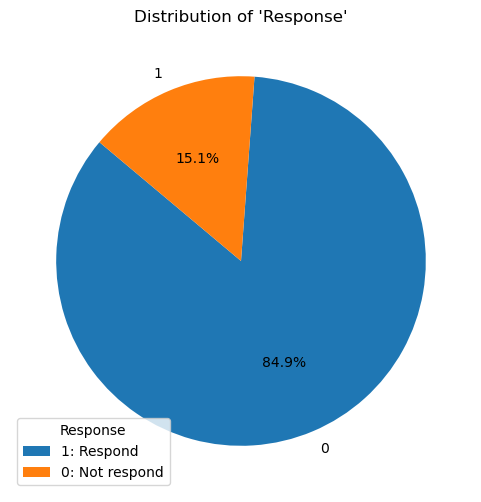

In [ ]:
# Count the occurrences of each category in 'Is_Parent'
response_counts = data['Response'].value_counts()

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(response_counts, labels=response_counts.index, autopct='%1.1f%%', startangle=140)

# Add a legend with explanation
plt.legend(
    wedges,
    ["1: Respond", "0: Not respond"],
    title="Response",
    loc="best"
)

plt.title("Distribution of 'Response'")
plt.show()

### Purchase Channel Distribution

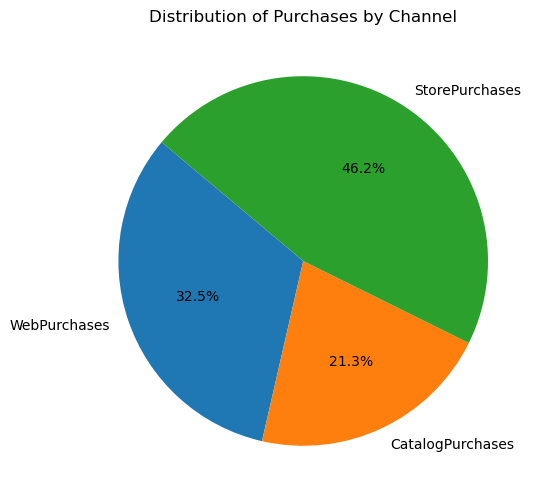

In [ ]:
# Renaming selected columns
rename_dict = {
    'NumWebPurchases': 'WebPurchases',
    'NumCatalogPurchases': 'CatalogPurchases',
    'NumStorePurchases': 'StorePurchases'
}

# Renaming columns in the dataframe
data_renamed = data.rename(columns=rename_dict)[list(rename_dict.values())]

# Summing each renamed column
sums_renamed = data_renamed.sum()

# Creating pie chart
plt.figure(figsize=(6, 6))
plt.pie(sums_renamed, labels=sums_renamed.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Purchases by Channel")
plt.show()

Store purchases are the primary purchasing channel, accounting for nearly half of all transactions.

### Deals Usage for Purchase

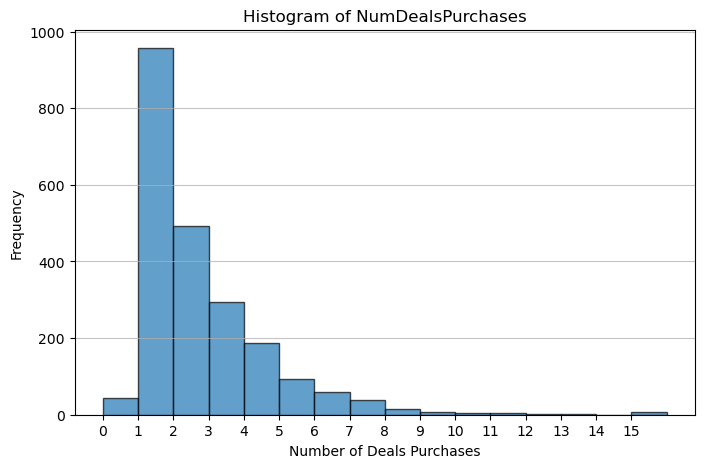

In [ ]:
# Generate the histogram with x-axis increments of 1
plt.figure(figsize=(8, 5))
plt.hist(data['NumDealsPurchases'], bins=np.arange(data['NumDealsPurchases'].min(), data['NumDealsPurchases'].max() + 2, 1),
         edgecolor='black', alpha=0.7)

plt.xlabel("Number of Deals Purchases")
plt.ylabel("Frequency")
plt.title("Histogram of NumDealsPurchases")
plt.xticks(np.arange(data['NumDealsPurchases'].min(), data['NumDealsPurchases'].max() + 1, 1))  # Set x-axis ticks at 1 increment
plt.grid(axis='y', alpha=0.75)
plt.show()

### AcceptedCmp

In [ ]:
# Extract the relevant columns
accepted_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
data_selected = data[accepted_cols]

# Count occurrences of 0 and 1 for each column
counts = data_selected.apply(pd.Series.value_counts).T

# Convert counts to percentages
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot histogram
percentages.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.xlabel("Campaigns")
plt.ylabel("Percentage")
plt.title("Percentage Distribution of Accepted Campaigns (0 vs 1)")
plt.xticks(rotation=45)
plt.legend(title="Response", labels=["Not Accepted (0)", "Accepted (1)"])
plt.show()


In [ ]:
data["TotalAccepted"] = data[accepted_cols].sum(axis=1)

# Convert to binary: 0 if no campaign accepted, 1 if at least one was accepted
data["AcceptedBinary"] = data["TotalAccepted"].apply(lambda x: 1 if x > 0 else 0)

# Count occurrences
counts = data["AcceptedBinary"].value_counts(normalize=True) * 100  # Convert to percentage

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=["Not Accepted (0)", "Accepted (1)"], autopct="%1.1f%%", startangle=90, colors=["lightpink", "lightblue"])
plt.title("Percentage of Customers Accepting At Least One Campaign")
plt.show()


In [ ]:
# Flatten the data: count total occurrences of 0 and 1 across all campaigns
counts = data[accepted_cols].values.flatten()
counts = pd.Series(counts).value_counts(normalize=True) * 100  # Convert to percentage

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=["Not Accepted (0)", "Accepted (1)"], autopct="%1.1f%%", startangle=90, colors=["lightpink", "lightblue"])
plt.title("Percentage of Acceptance Across All Campaigns")
plt.show()


The higher acceptance rate among customers who accepted at least one campaign, compared to the overall acceptance rate for individual campaigns, suggests that although many customers are open to promotions, they are selective and only engage with offers that align with their specific interests. This highlights the need for more targeted and personalized marketing strategies to improve individual campaign effectiveness and overall customer engagement.

### Complain

In [ ]:
# 1=complain
complain_counts = data['Complain'].value_counts()
complain_counts

Complain
0    2192
1      20
Name: count, dtype: int64

In [ ]:
# Calculate percentage
complain_percentage = (complain_counts / data.shape[0]) * 100

# Display results
print(complain_percentage)

Complain
0    99.095841
1     0.904159
Name: count, dtype: float64


Complain percentage is lower than 1%, which is acceptable, meaning customers are satisfactory with our products in general.

### Spent

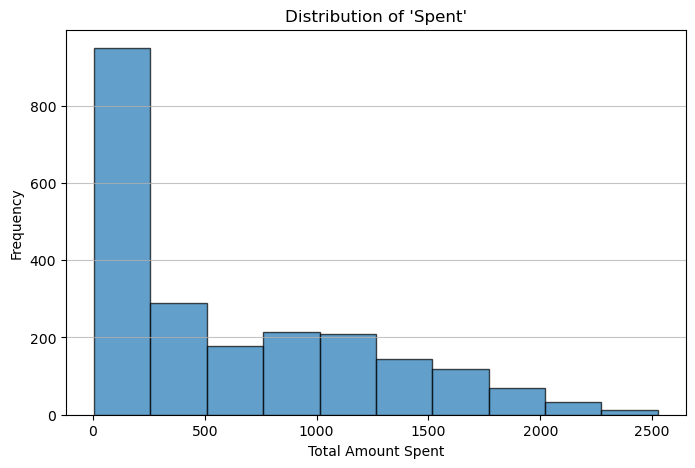

In [ ]:
# Generate a histogram for the 'Spent' column to visualize its distribution
plt.figure(figsize=(8, 5))
plt.hist(data['Spent'], bins=10, edgecolor='black', alpha=0.7)
plt.xlabel("Total Amount Spent")
plt.ylabel("Frequency")
plt.title("Distribution of 'Spent'")
plt.grid(axis='y', alpha=0.75)
plt.show()

Majority customers spend less than $250.

### Recency

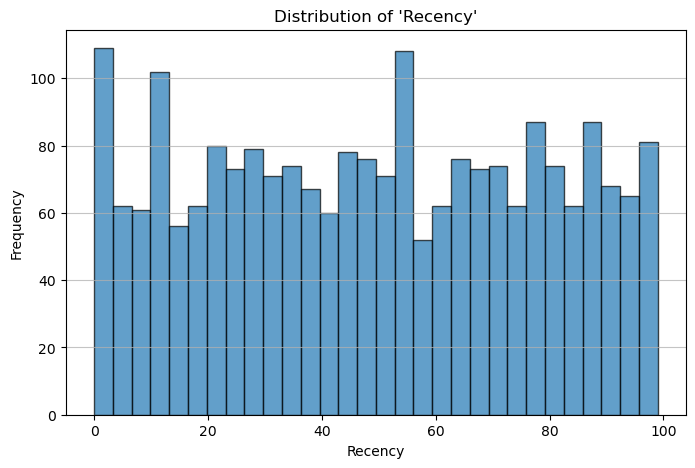

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(data['Recency'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("Distribution of 'Recency'")
plt.grid(axis='y', alpha=0.75)
plt.show()

The histogram of Recency shows a relatively uniform distribution, indicating that customers have made purchases at various intervals. Peaks at specific values suggest that some groups of customers tend to make purchases at common time intervals, such as due to subscription or loyalty programs. This insight can help in tailoring marketing strategies for different customer segments based on their purchase behavior.

# Data Preprocessing

### One-hot encoding

In [ ]:
# Perform one-hot encoding on categorical columns: 'Education' and 'Living_With'
categorical_columns = ['Education', 'Living_With']

# Apply one-hot encoding
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)  # drop_first=True to avoid multicollinearity

<Axes: >

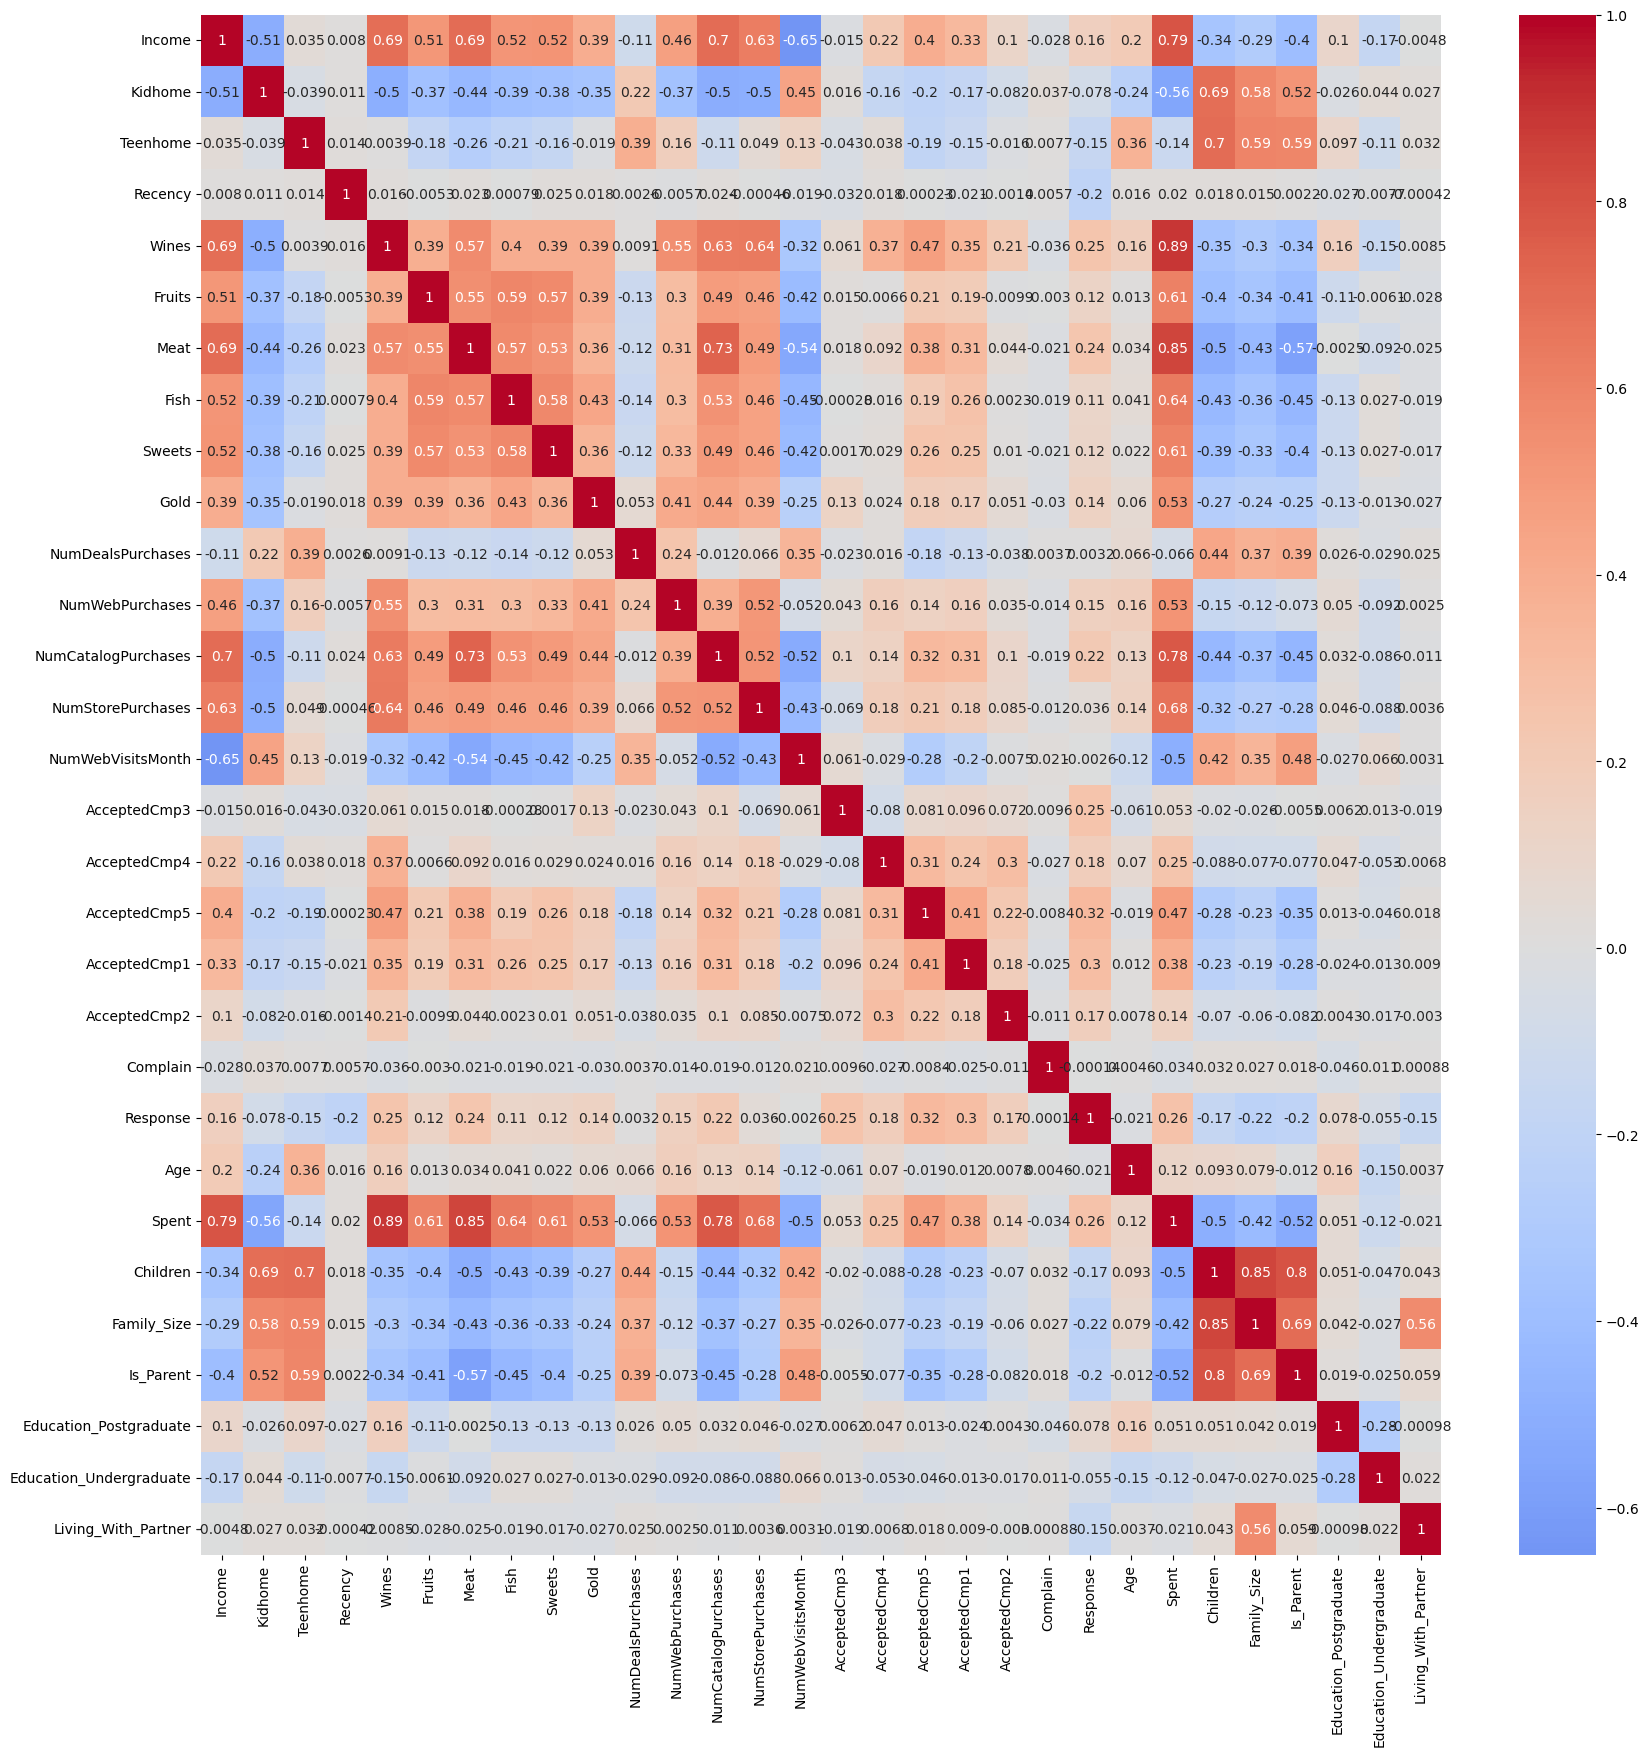

In [ ]:
#correlation matrix
corrmat= data_encoded.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corrmat,annot=True, cmap='coolwarm', center=0)

We noticed that some features exhibit high correlation (> 0.8). For example, `Wines`, `Income`, and `Meat` are strongly related to `Spent`, while `Family_Size` and `Children` are also highly correlated. To address this, we will analyze their impact and consider dimensionality reduction or feature selection later when modeling to prevent redundancy and ensure meaningful clustering results.

### PCA

In [ ]:
# Standardize the data
data_scaled = StandardScaler().fit_transform(data_encoded)

# Apply PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(data_scaled)

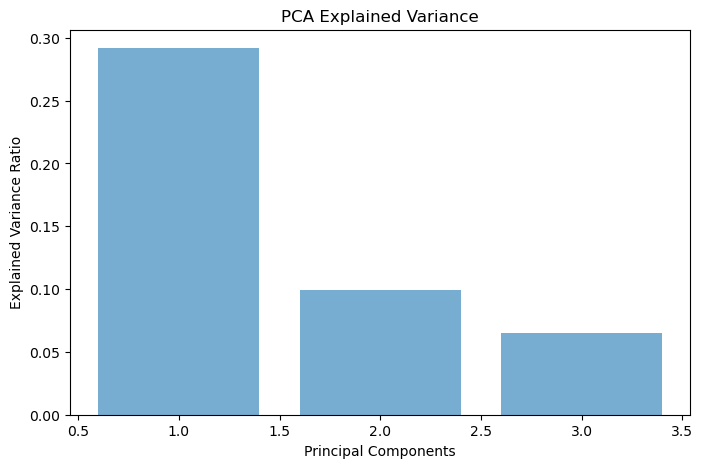

In [ ]:
# Create a DataFrame for visualization
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])

# Explained variance plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.6)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.show()

In [ ]:
pca_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,2212.0,-2.505530e-16,2.959464,-5.861170,-2.563286,-0.851787,2.259655,8.527555
PC2,2212.0,-1.413376e-16,1.725050,-4.561578,-1.342232,-0.122662,1.240667,6.121466
PC3,2212.0,4.818328e-18,1.393866,-3.589525,-0.696765,-0.130970,0.407758,8.850807


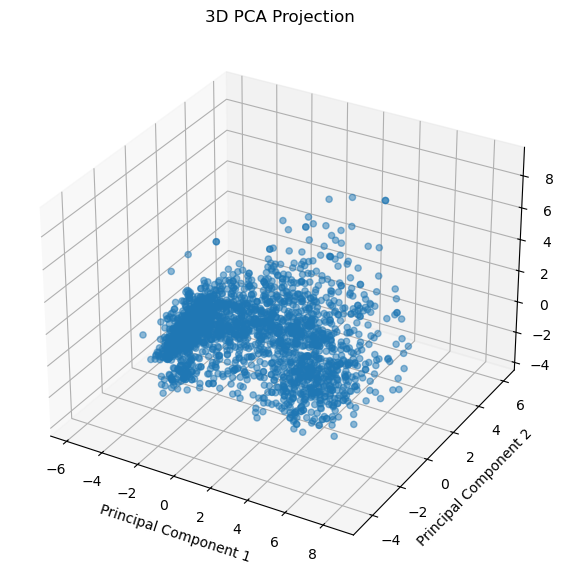

In [ ]:
# 3D Scatter plot of first three principal components
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], alpha=0.5)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Projection')
plt.show()

In [ ]:
# Print explained variance
print("Explained Variance Ratios:", pca.explained_variance_ratio_)

Explained Variance Ratios: [0.29181552 0.09914839 0.06473279]


PC1 explains 29.2% of the total variance.
PC2 explains 9.9% of the total variance.
PC3 explains 6.5% of the total variance.
Together, these three components explain ~45.5% of the total variance, meaning there's still a significant amount of variance left unexplained.

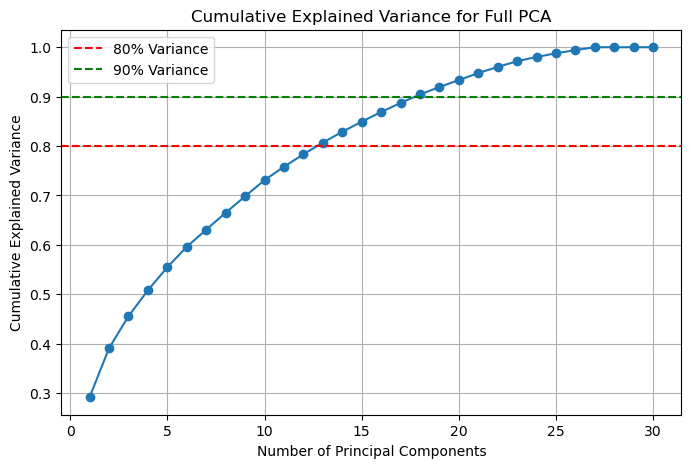

In [ ]:
pca_full = PCA().fit(data_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Variance')
plt.axhline(y=0.9, color='g', linestyle='--', label='90% Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance for Full PCA')
plt.legend()
plt.grid()
plt.show()


15 principal components are needed to explain 80% of the variance, so we use PCA with 15 components.

In [ ]:
# Reduce to 15 principal components
pca = PCA(n_components=15)
pca_data = pca.fit_transform(data_encoded)

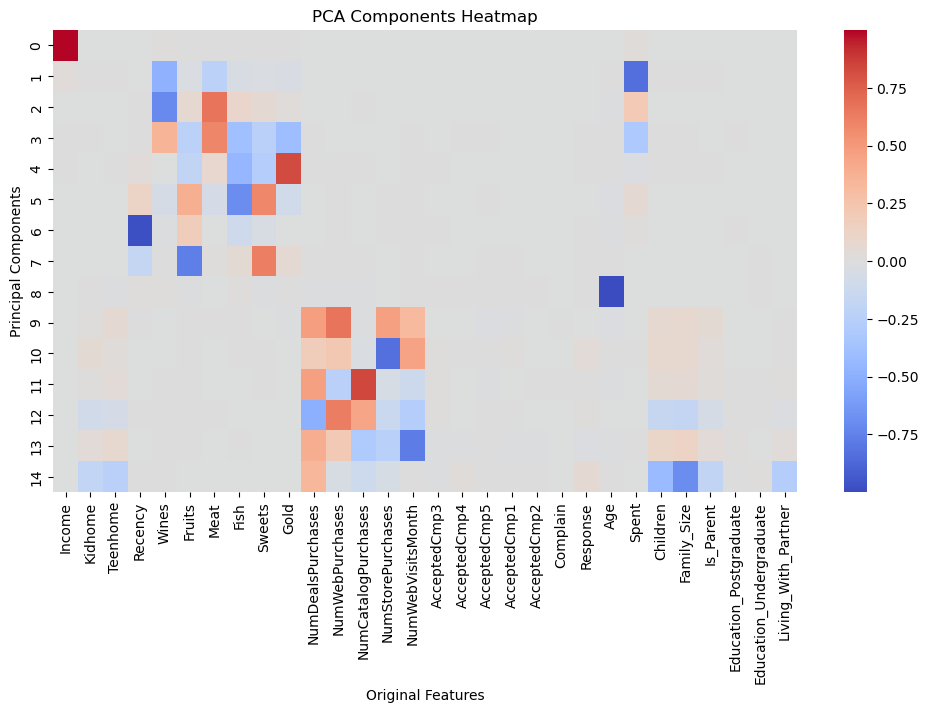

In [ ]:
# Create a DataFrame of PCA components
pca_components = pd.DataFrame(pca.components_, columns=data_encoded.columns)

plt.figure(figsize=(12, 6))
sns.heatmap(pca_components, cmap='coolwarm', center=0)
plt.xlabel('Original Features')
plt.ylabel('Principal Components')
plt.title('PCA Components Heatmap')
plt.show()

In [ ]:
pd.DataFrame(pca_data).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,6206.167332,-948.575844,239.771964,-74.275567,-43.125840,-22.350598,-11.416423,-0.282941,-15.045468,0.714109,5.753004,2.830750,2.511197,-1.546633,0.824587
1,-5630.285011,527.712456,-17.169121,22.747195,-3.848358,-4.087230,9.537087,0.930076,-14.566481,-2.604032,1.030967,0.525020,-0.611709,0.385017,-0.056111
2,19652.519752,310.916333,-109.952038,-60.860036,-40.725607,-45.355119,18.856866,-15.452189,-0.013271,2.635110,-1.538564,-2.569883,1.733022,-0.182757,0.586529
3,-25321.043196,-4.142796,40.669413,14.222641,-13.719720,-4.637652,21.993104,3.346413,11.697365,-0.221011,-1.225092,-0.182525,0.086276,0.628375,-0.332255
4,6326.189935,394.129082,9.692348,-11.598350,-27.623618,8.185536,-42.266492,-22.253147,13.208282,2.996384,0.813616,1.780373,-0.403991,1.030138,0.552850


The number of principal components in the plot which shows the cumulative explained variance of PCA components needed to retain 95% of variance is 22 out of 28 features. This suggests that PCA may not significantly reduce dimensionality while preserving information.


# Clustering & Segmentation


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Step 1: Define numerical and categorical columns
categorical_cols = ['Education', 'Living_With']
numerical_cols = data.select_dtypes(exclude=['object']).columns

# Step 2: One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(data[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols), index=data.index)

# Step 3: Impute missing values in numerical columns (ONLY numerical data)
imputer = SimpleImputer(strategy='mean')
data_numeric_imputed = pd.DataFrame(imputer.fit_transform(data[numerical_cols]),
                                    columns=numerical_cols,
                                    index=data.index)

# Step 4: Standardize numerical data
scaler = StandardScaler()
data_numeric_scaled = pd.DataFrame(scaler.fit_transform(data_numeric_imputed),
                                   columns=numerical_cols,
                                   index=data.index)

data_scaled = pd.concat([data_numeric_scaled, encoded_df], axis=1)




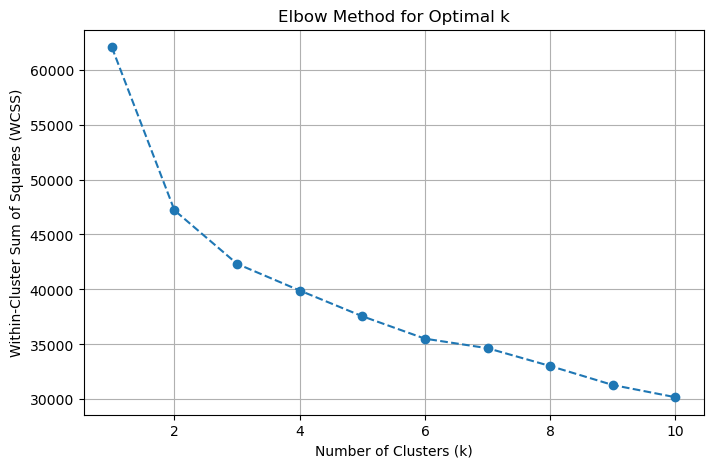

In [ ]:
wcss = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

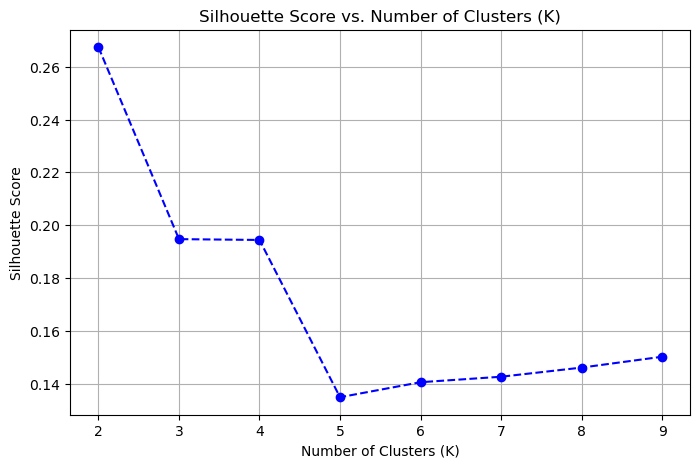

In [ ]:
k_values = range(2, 10)  # Testing K from 2 to 9
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, cluster_labels)
    silhouette_scores.append(score)

# Plot Silhouette Score vs. Number of Clusters (K)
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters (K)")
plt.grid(True)
plt.show()

## K-means Clustering

### k =3


In [ ]:

optimal_k = 3
kmeans3 = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters3 = kmeans3.fit_predict(data_scaled)
data["Segment_k3"] = clusters3
segment_distribution3 = data["Segment_k3"].value_counts().sort_index()
print(segment_distribution3)


Segment_k3
0     514
1     637
2    1061
Name: count, dtype: int64


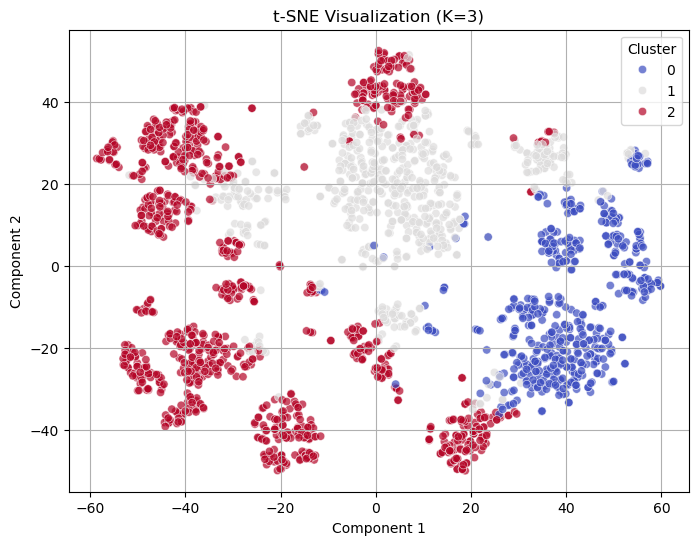

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


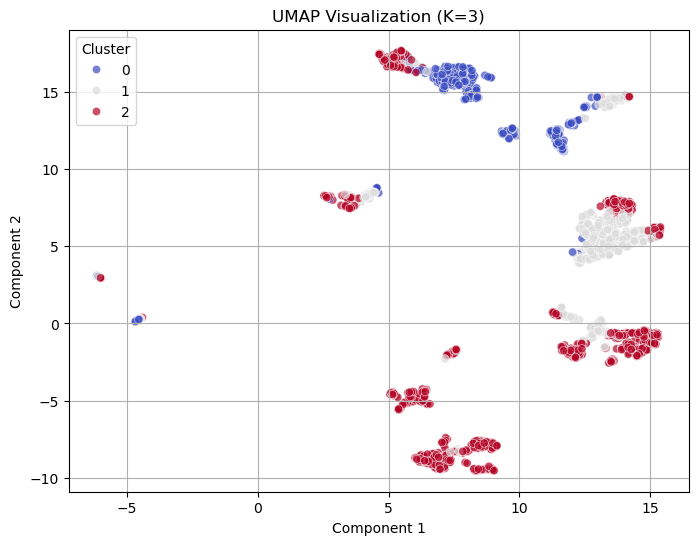

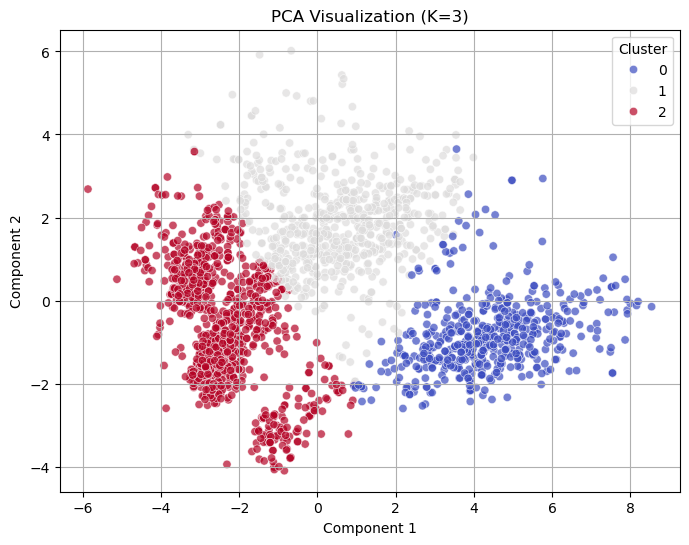

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
import umap.umap_ as umap

def plot_clustering(X_embedded, labels, title):
    """Helper function to plot clustering results"""
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=labels, palette="coolwarm", alpha=0.7)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(title="Cluster")
    plt.grid(True)
    plt.show()



# Run t-SNE for K=3
tsne_k3 = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results_k3 = tsne_k3.fit_transform(data_scaled)
plot_clustering(tsne_results_k3, data["Segment_k3"], "t-SNE Visualization (K=3)")

# Run UMAP for K=3
umap_k3 = umap.UMAP(n_components=2, random_state=42)
umap_results_k3 = umap_k3.fit_transform(data_scaled)
plot_clustering(umap_results_k3, data["Segment_k3"], "UMAP Visualization (K=3)")

#PCA visualization for K=3
pca = PCA(n_components=2)
pca_results = pca.fit_transform(data_scaled)
plot_clustering(pca_results, data["Segment_k3"], "PCA Visualization (K=3)")





### k =4


In [ ]:
optimal_k = 4
kmeans4 = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters4 = kmeans4.fit_predict(data_scaled)
data["Segment_k4"] = clusters4
segment_distribution4 = data["Segment_k4"].value_counts().sort_index()
print(segment_distribution4)

Segment_k4
0    501
1    619
2    510
3    582
Name: count, dtype: int64


reasonable since evenly distributed

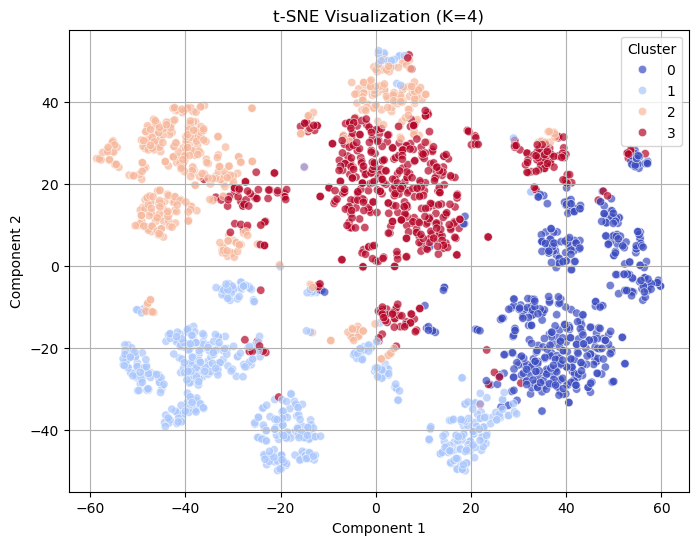

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


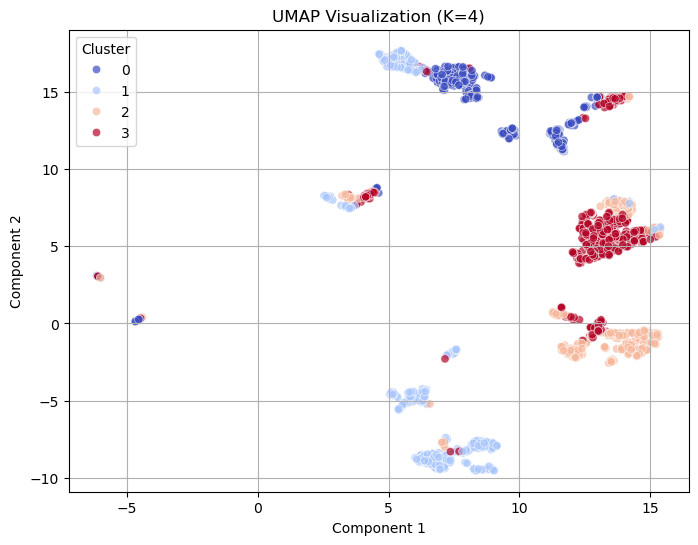

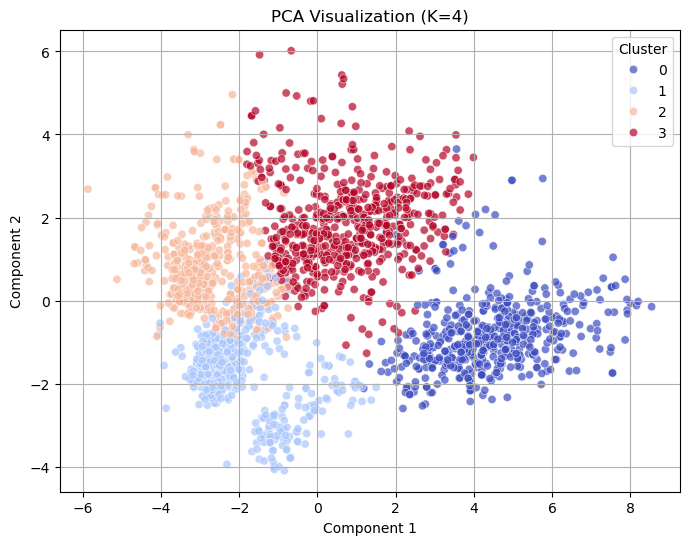

In [ ]:
# Run t-SNE for K=4
tsne_k4 = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results_k4 = tsne_k4.fit_transform(data_scaled)
plot_clustering(tsne_results_k4, data["Segment_k4"], "t-SNE Visualization (K=4)")

# Run UMAP for K=4
umap_k4 = umap.UMAP(n_components=2, random_state=42)
umap_results_k4 = umap_k4.fit_transform(data_scaled)
plot_clustering(umap_results_k4, data["Segment_k4"], "UMAP Visualization (K=4)")

#PCA visualization for K=4
pca = PCA(n_components=2)
pca_results = pca.fit_transform(data_scaled)
plot_clustering(pca_results, data["Segment_k4"], "PCA Visualization (K=4)")

The number of principal components in the plot which shows the cumulative explained variance of PCA components needed to retain 95% of variance is 22 out of 28 features. This suggests that PCA may not significantly reduce dimensionality while preserving information.

Then we try t-SNE. From the plot, several dense clusters are visible, indicating that natural groupings exist in the dataset. ome clusters are well-separated, suggesting that certain customer segments are clearly distinct. However, some overlapping regions might indicate fuzzy boundaries between groups. The visualization suggests around 4 to 6 primary clusters, this aligns with the Elbow Method, which suggested an optimal k=4.

Since t-SNE does not preserve cluster density or distances well, we finally choose to not conduct dimensional reduction in this business case.

## Other Clustering Methods

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data_scaled['KMeans_Labels'] = kmeans.fit_predict(data_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=5)
data_scaled['DBSCAN_Labels'] = dbscan.fit_predict(data_scaled)

hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
data_scaled['Hierarchical_Labels'] = hierarchical.fit_predict(data_scaled)

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
data_scaled['GMM_Labels'] = gmm.fit_predict(data_scaled)

metrics_results = {
    "K-Means": {
        "Silhouette Score": silhouette_score(data_scaled.drop(columns=['DBSCAN_Labels']), data_scaled['KMeans_Labels']),
        "Davies-Bouldin Score": davies_bouldin_score(data_scaled.drop(columns=['DBSCAN_Labels']), data_scaled['KMeans_Labels'])
    },
    "Hierarchical": {
        "Silhouette Score": silhouette_score(data_scaled.drop(columns=['DBSCAN_Labels']), data_scaled['Hierarchical_Labels']),
        "Davies-Bouldin Score": davies_bouldin_score(data_scaled.drop(columns=['DBSCAN_Labels']), data_scaled['Hierarchical_Labels'])
    },
    "GMM": {
        "Silhouette Score": silhouette_score(data_scaled.drop(columns=['DBSCAN_Labels']), data_scaled['GMM_Labels']),
        "Davies-Bouldin Score": davies_bouldin_score(data_scaled.drop(columns=['DBSCAN_Labels']), data_scaled['GMM_Labels'])
    },
    "DBSCAN": {
        "Silhouette Score": silhouette_score(data_scaled, data_scaled['DBSCAN_Labels']),
        "Davies-Bouldin Score": davies_bouldin_score(data_scaled, data_scaled['DBSCAN_Labels'])
    }
}

print("Clustering Performance Metrics:")
for model, scores in metrics_results.items():
    print(f"\n{model}:")
    for metric, value in scores.items():
        print(f"  {metric}: {value:.4f}")

Clustering Performance Metrics:

K-Means:
  Silhouette Score: 0.2325
  Davies-Bouldin Score: 1.7788

Hierarchical:
  Silhouette Score: 0.0397
  Davies-Bouldin Score: 2.5262

GMM:
  Silhouette Score: 0.0782
  Davies-Bouldin Score: 2.0856


Since DBSCAN does not define clusters as clearly, it was excluded from performance metrics. With the highest Silhouette Score and the lowest Davies-Bouldin Score, **K-means** clustering shows the best model performace.

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


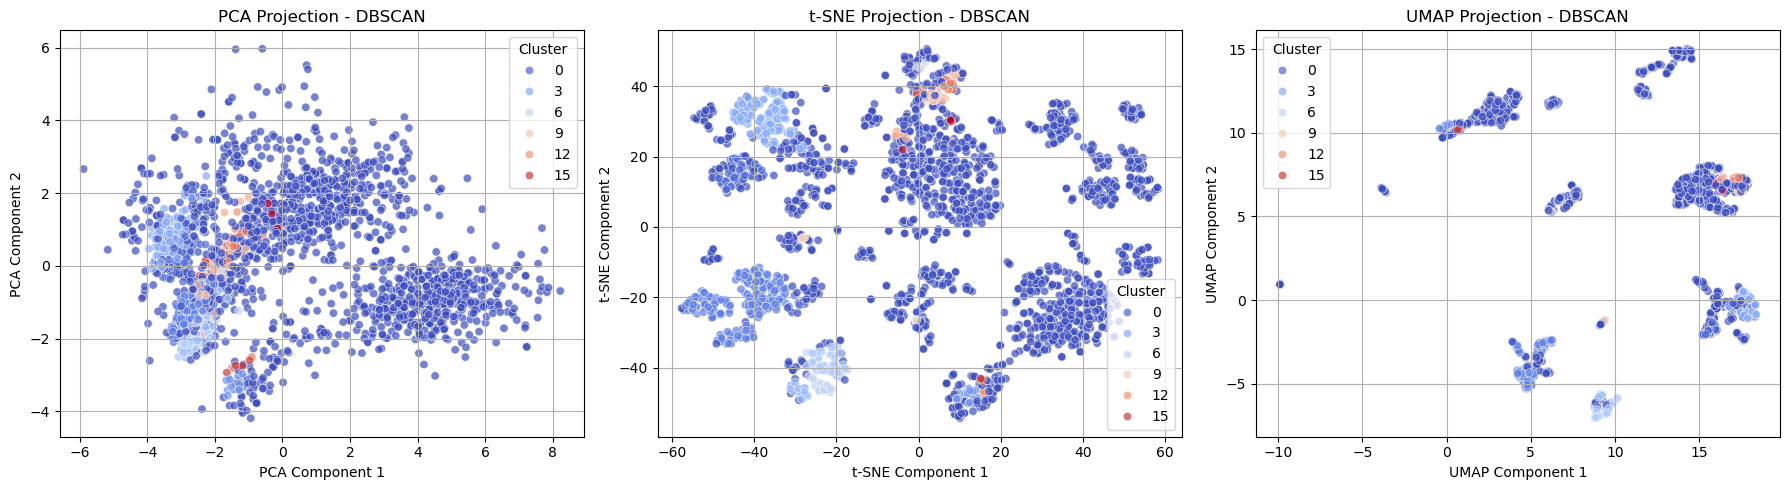

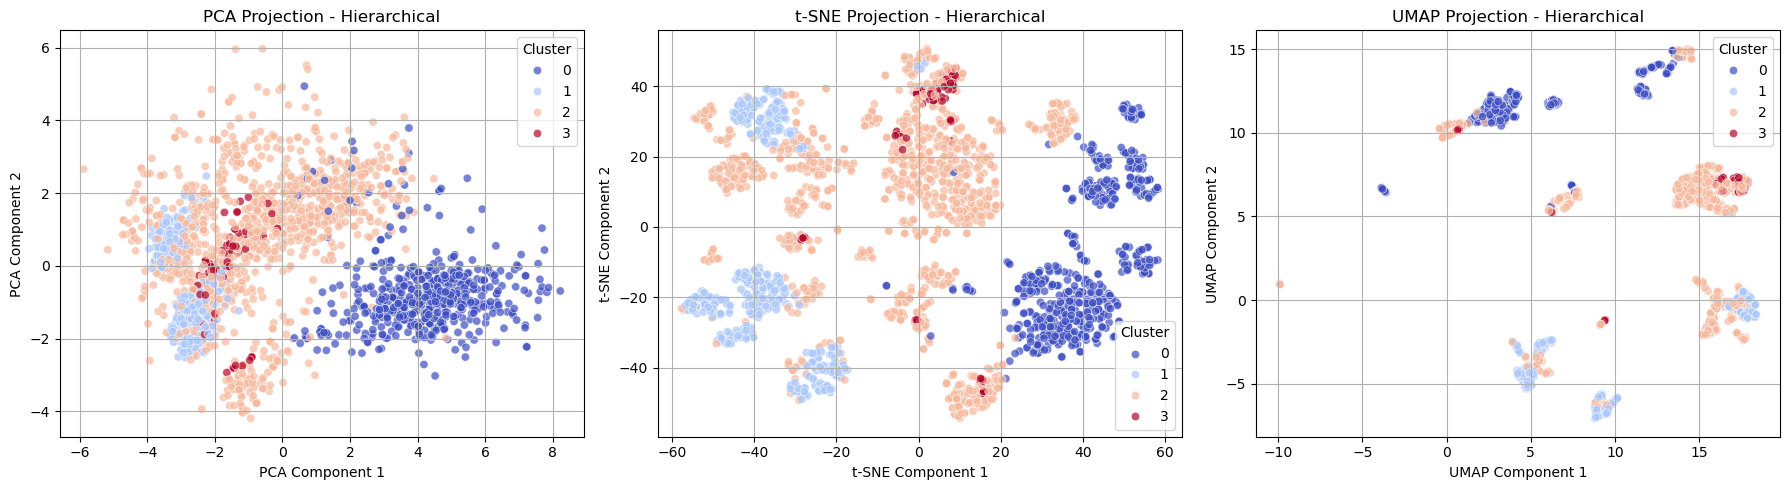

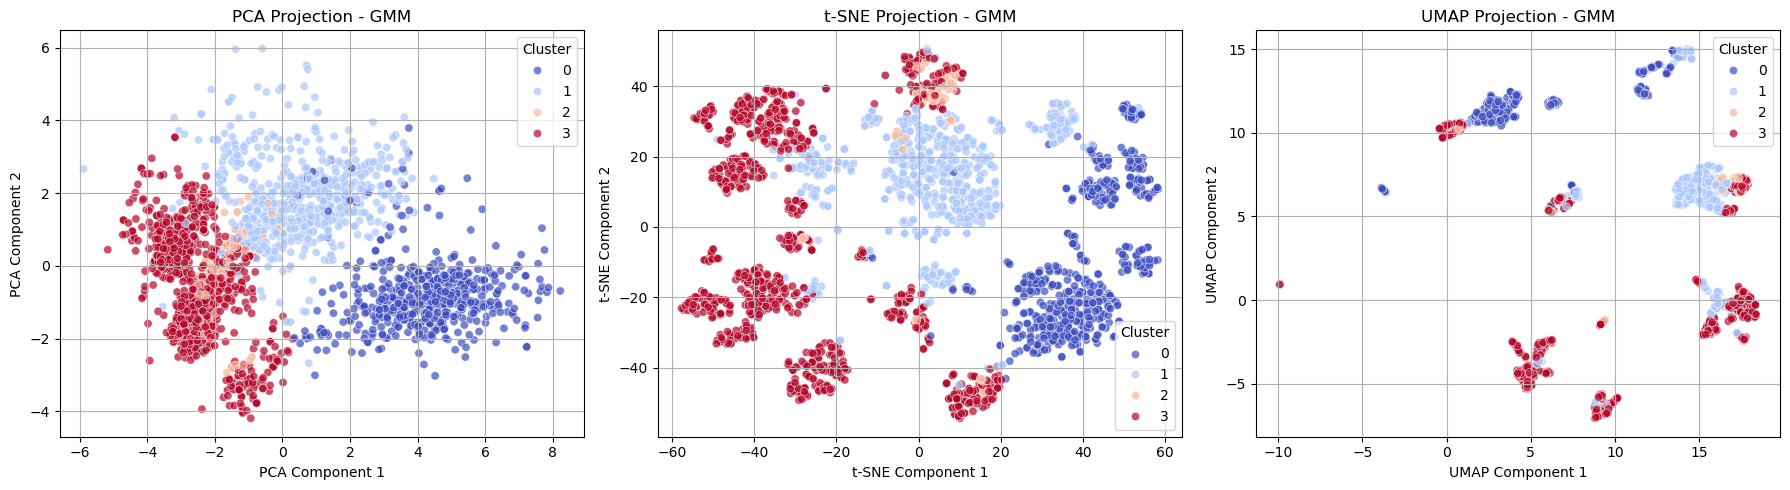

In [ ]:

# Define clustering labels
clustering_methods = {
    "DBSCAN": "DBSCAN_Labels",
    "Hierarchical": "Hierarchical_Labels",
    "GMM": "GMM_Labels"
}

# Drop clustering label columns for dimensionality reduction
features_only = data_scaled.drop(columns=list(clustering_methods.values()), errors='ignore')

# ---------- PCA ----------
pca_results = PCA(n_components=2).fit_transform(features_only)

# ---------- t-SNE ----------
tsne_results = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(features_only)

# ---------- UMAP ----------
umap_results = umap.UMAP(n_components=2, random_state=42).fit_transform(features_only)

# Define projections
projections = {"PCA": pca_results, "t-SNE": tsne_results, "UMAP": umap_results}

# Plot projections for each clustering method
for method, label in clustering_methods.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (proj_name, proj_data) in enumerate(projections.items()):
        sns.scatterplot(x=proj_data[:, 0], y=proj_data[:, 1], hue=data_scaled[label],
                        palette="coolwarm", alpha=0.7, ax=axes[i])
        axes[i].set_title(f"{proj_name} Projection - {method}")
        axes[i].set_xlabel(f"{proj_name} Component 1")
        axes[i].set_ylabel(f"{proj_name} Component 2")
        axes[i].legend(title="Cluster")
        axes[i].grid(True)
    plt.tight_layout()
    plt.show()


**ACTION NEEDED**

putting the visualization of clusters on GMM, Hierarchical, DBSCAN in Appendix just in case of Q&A


# Customer Profiling



## k = 3

In [ ]:
numerical_summary = data.groupby("Segment_k3")[numerical_cols].mean().round(1)

categorical_distributions = []

for cat in categorical_cols:
    cat_distribution = (
        data.groupby("Segment_k3")[cat]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0) * 100
    )
    cat_distribution = cat_distribution.applymap(lambda x: f"{x:.1f}%")

    cat_distribution.columns = [f"{level} ({cat})" for level in cat_distribution.columns]

    categorical_distributions.append(cat_distribution)

categorical_summary = pd.concat(categorical_distributions, axis=1)

cluster_summary = pd.concat([numerical_summary, categorical_summary], axis=1)

cluster_summaryT = cluster_summary.T

cluster_sizes = data["Segment_k3"].value_counts().sort_index().rename("Cluster Size").to_frame().T

cluster_summary_k3 = pd.concat([cluster_sizes, cluster_summaryT])
cluster_summary_k3

/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/1651250958.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cat_distribution = cat_distribution.applymap(lambda x: f"{x:.1f}%")
/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/1651250958.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cat_distribution = cat_distribution.applymap(lambda x: f"{x:.1f}%")


Segment_k3,0,1,2
Cluster Size,514,637,1061
Income,76061.8,60317.8,35263.6
Kidhome,0.0,0.2,0.8
Teenhome,0.0,1.0,0.5
Recency,49.4,48.3,49.3
Wines,619.0,482.5,46.9
Fruits,64.0,31.4,5.0
Meat,470.7,158.6,25.0
Fish,95.3,41.5,7.4
Sweets,66.0,32.2,5.0


Cluster 0: Elite Shoppers	High-income, high-spending, omnichannel buyers	VIP loyalty programs, premium bundles, luxury events

Cluster 1: Balanced Shoppers	Middle-income, omnichannel, buys a mix of essentials & discretionary items	Cross-channel promotions, hybrid discounts, personalized recommendations

Cluster 2: Budget-Conscious Families	Low-income, large families, deal seekers	Discount promotions, budget bundles, flash sales

## k = 4

In [ ]:
numerical_summary = data.groupby("Segment_k4")[numerical_cols].mean().round(1)

categorical_distributions = []

for cat in categorical_cols:
    cat_distribution = (
        data.groupby("Segment_k4")[cat]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0) * 100
    )
    cat_distribution = cat_distribution.applymap(lambda x: f"{x:.1f}%")

    cat_distribution.columns = [f"{level} ({cat})" for level in cat_distribution.columns]

    categorical_distributions.append(cat_distribution)

categorical_summary = pd.concat(categorical_distributions, axis=1)

cluster_summary = pd.concat([numerical_summary, categorical_summary], axis=1)

cluster_summaryT = cluster_summary.T

cluster_sizes = data["Segment_k4"].value_counts().sort_index().rename("Cluster Size").to_frame().T

cluster_summary_k4 = pd.concat([cluster_sizes, cluster_summaryT])
cluster_summary_k4


/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/2903153633.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cat_distribution = cat_distribution.applymap(lambda x: f"{x:.1f}%")
/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/2903153633.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cat_distribution = cat_distribution.applymap(lambda x: f"{x:.1f}%")


Segment_k4,0,1,2,3
Cluster Size,501,619,510,582
Income,76523.0,30873.8,42526.6,61504.2
Kidhome,0.0,0.7,0.8,0.2
Teenhome,0.0,0.0,1.0,1.0
Recency,49.0,49.3,49.0,48.7
Wines,626.0,39.9,77.4,511.2
Fruits,64.2,7.0,4.1,33.8
Meat,477.4,28.8,28.1,168.7
Fish,95.5,10.9,5.7,44.4
Sweets,66.8,7.1,4.0,34.2




Cluster 0: Premium Shoppers	High-income, luxury-focused, loyal spenders	VIP programs, premium product bundles, early-access sales

Cluster 1: Budget-Conscious Families	Low-income, large families, high browsing, low spending	Discount promotions, family bundles, free shipping incentives

Cluster 2: Senior Deal Hunters	Older, price-sensitive, necessity-focused	Senior discounts, targeted deals on essentials, simplified checkout

Cluster 3: Omnichannel Moderate Spenders	Balanced online & in-store, mid-income, enjoys variety	Hybrid promotions, personalized offers, cross-channel discounts


## MKT Mix

<Figure size 1000x600 with 0 Axes>

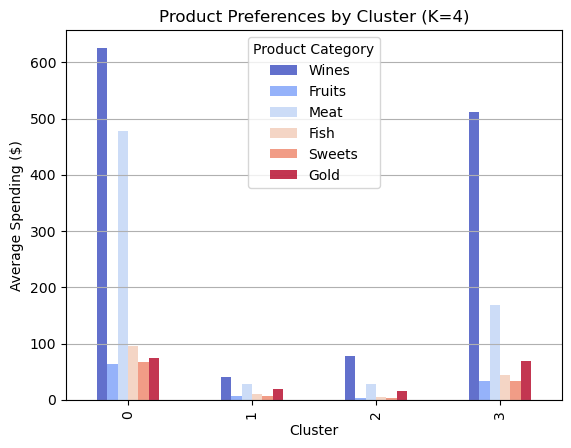

<Figure size 1000x600 with 0 Axes>

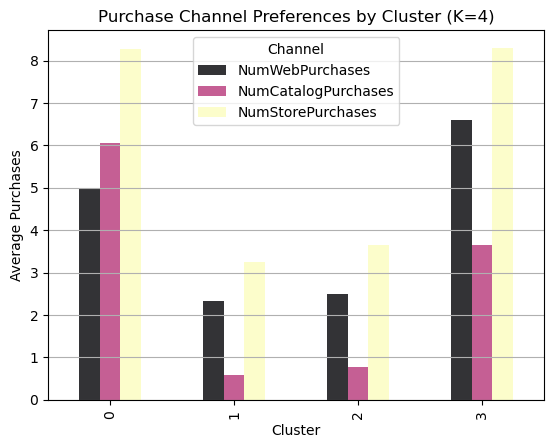

<Figure size 1000x600 with 0 Axes>

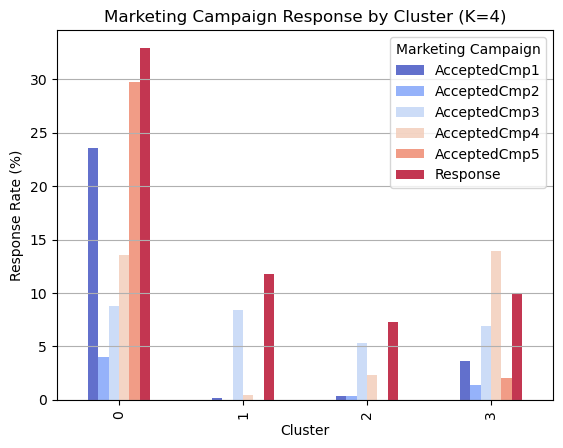

In [ ]:
###
import matplotlib.pyplot as plt
import seaborn as sns

# Define the 4P-related features
product_columns = ["Wines", "Fruits", "Meat", "Fish", "Sweets", "Gold"]
price_columns = ["Spent", "Income"]
place_columns = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
promotion_columns = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]

# Compute mean values per cluster
product_summary = data.groupby("Segment_k4")[product_columns].mean()
price_summary = data.groupby("Segment_k4")[price_columns].mean()
place_summary = data.groupby("Segment_k4")[place_columns].mean()
promotion_summary = data.groupby("Segment_k4")[promotion_columns].mean() * 100  # Convert to percentage

# Plot Product (Spending on different categories)
plt.figure(figsize=(10,6))
product_summary.plot(kind="bar", colormap="coolwarm", alpha=0.8)
plt.title("Product Preferences by Cluster (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Average Spending ($)")
plt.legend(title="Product Category")
plt.grid(axis="y")
plt.show()


# Plot Place (Preferred Purchase Channels)
plt.figure(figsize=(10,6))
place_summary.plot(kind="bar", colormap="magma", alpha=0.8)
plt.title("Purchase Channel Preferences by Cluster (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Average Purchases")
plt.legend(title="Channel")
plt.grid(axis="y")
plt.show()

# Plot Promotion (Marketing Campaign Response)
plt.figure(figsize=(10,6))
promotion_summary.plot(kind="bar", colormap="coolwarm", alpha=0.8)
plt.title("Marketing Campaign Response by Cluster (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Response Rate (%)")
plt.legend(title="Marketing Campaign")
plt.grid(axis="y")
plt.show()


<Figure size 1000x600 with 0 Axes>

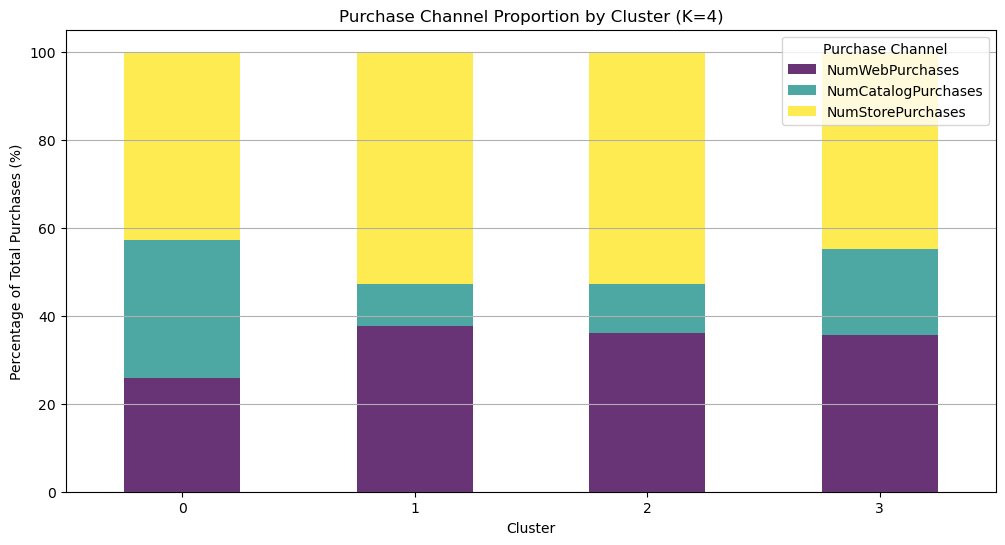

/var/folders/yg/nqwl1cnn1dqdv2h8t0hg44hh0000gn/T/ipykernel_19521/2110041437.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Segment_k4", y="NumDealsPurchases", palette="coolwarm")


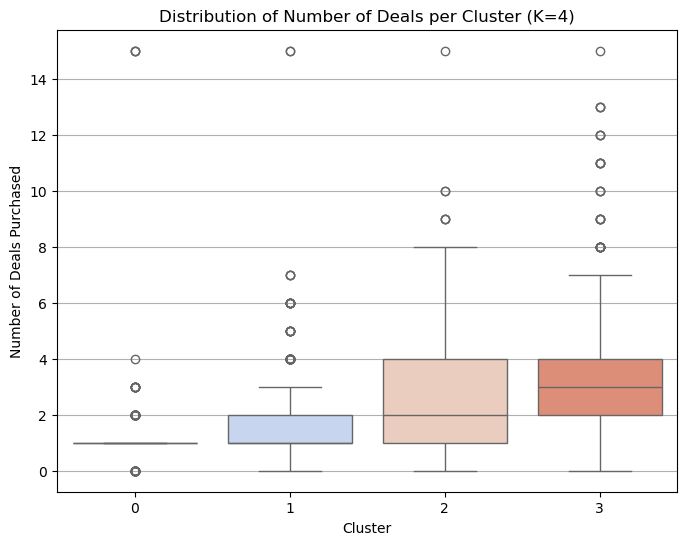

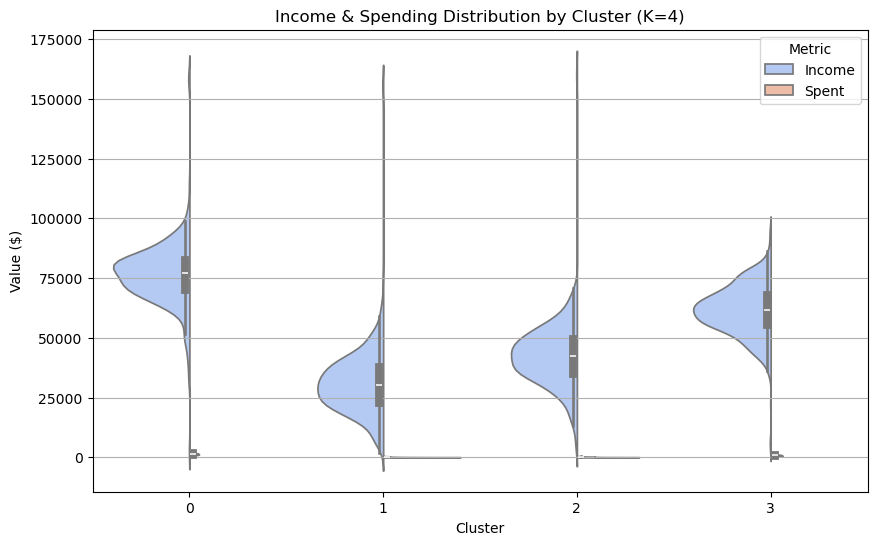

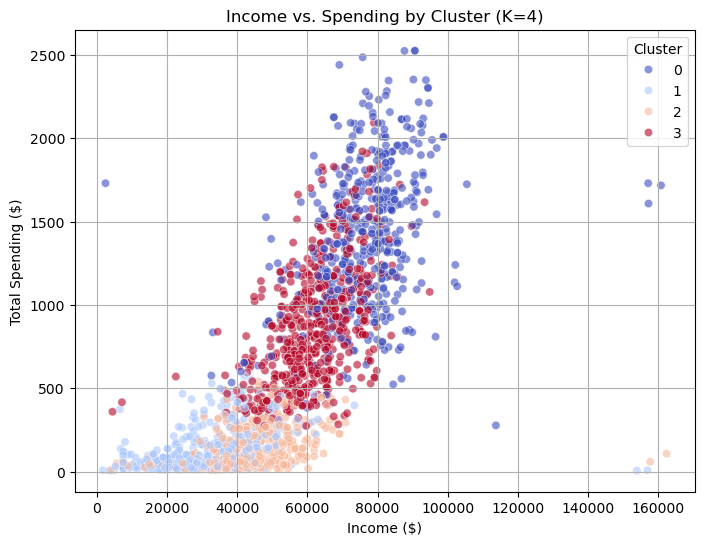

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1️⃣ PURCHASE CHANNEL PORTION PER CLUSTER ----------
# Compute total purchases per cluster
total_purchases = data.groupby("Segment_k4")[["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].sum()
# Convert to proportion within each cluster
purchase_portion = total_purchases.div(total_purchases.sum(axis=1), axis=0) * 100

# Plot purchase channel portion
plt.figure(figsize=(10,6))
purchase_portion.plot(kind="bar", stacked=True, colormap="viridis", alpha=0.8, figsize=(12,6))
plt.title("Purchase Channel Proportion by Cluster (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Total Purchases (%)")
plt.legend(title="Purchase Channel")
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.show()

# ---------- 2️⃣ DISTRIBUTION OF NUMBER OF DEALS PER CLUSTER ----------
plt.figure(figsize=(8,6))
sns.boxplot(data=data, x="Segment_k4", y="NumDealsPurchases", palette="coolwarm")
plt.title("Distribution of Number of Deals per Cluster (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Number of Deals Purchased")
plt.grid(axis="y")
plt.show()

# ---------- 3️⃣ REVISED DISTRIBUTION OF INCOME & SPENDING PER CLUSTER ----------
plt.figure(figsize=(10,6))
sns.violinplot(data=data.melt(id_vars=["Segment_k4"], value_vars=["Income", "Spent"]),
               x="Segment_k4", y="value", hue="variable", split=True, palette="coolwarm")
plt.title("Income & Spending Distribution by Cluster (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Value ($)")
plt.legend(title="Metric")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x="Income", y="Spent", hue="Segment_k4", palette="coolwarm", alpha=0.6)
plt.title("Income vs. Spending by Cluster (K=4)")
plt.xlabel("Income ($)")
plt.ylabel("Total Spending ($)")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()



# Make Predictions (Supervised Learning)

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Split the data by cluster
clusters = data['Segment_k4'].unique()

# Initialize dictionaries to store models and their performance
models = {}
performance = {}

In [ ]:
# Loop through each cluster
for cluster in clusters:
    print(f"Processing Cluster {cluster}...")

    # Filter data for the current cluster and reset index
    cluster_data = data[data['Segment_k4'] == cluster].reset_index(drop=True)

    # Separate features and target
    X = cluster_data.drop(columns=['Response', 'Segment_k4'])
    y = cluster_data['Response']

    # Identify categorical columns
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

    # One-hot encode categorical columns
    if categorical_cols:
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded_features = encoder.fit_transform(X[categorical_cols])
        encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

        # Drop original categorical columns and concatenate encoded ones
        X = X.drop(columns=categorical_cols)
        X = pd.concat([X, encoded_df], axis=1)

    # Verify shapes of X and y
    print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Train a Random Forest Classifier
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    # Store the model and its performance
    models[cluster] = model
    performance[cluster] = {
        'accuracy': accuracy,
        'classification_report': report
    }

    # Print the performance
    print(f"Cluster {cluster} - Accuracy: {accuracy:.2f}")
    print(f"Classification Report:\n{report}")

Processing Cluster 0...
Shape of X: (501, 30), Shape of y: (501,)
Cluster 0 - Accuracy: 0.75
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.94      0.83       101
           1       0.75      0.36      0.49        50

    accuracy                           0.75       151
   macro avg       0.75      0.65      0.66       151
weighted avg       0.75      0.75      0.72       151

Processing Cluster 2...
Shape of X: (510, 30), Shape of y: (510,)
Cluster 2 - Accuracy: 0.92
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.96       139
           1       1.00      0.07      0.13        14

    accuracy                           0.92       153
   macro avg       0.96      0.54      0.54       153
weighted avg       0.92      0.92      0.88       153

Processing Cluster 1...
Shape of X: (619, 30), Shape of y: (619,)
Cluster 1 - Accuracy: 0.90
Classification Report


Evaluating Model for Cluster 0:
Training Accuracy: 1.00
Testing Accuracy: 0.75

Confusion Matrix (Testing Data):
[[95  6]
 [32 18]]


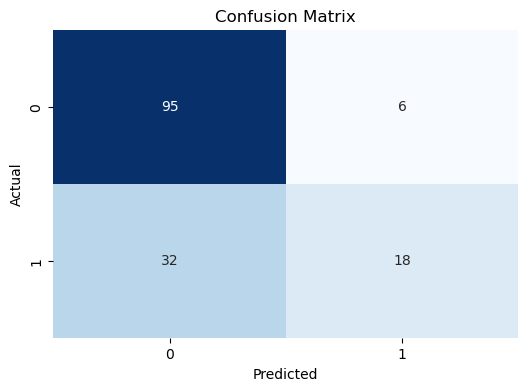

AUC-ROC Score: 0.83


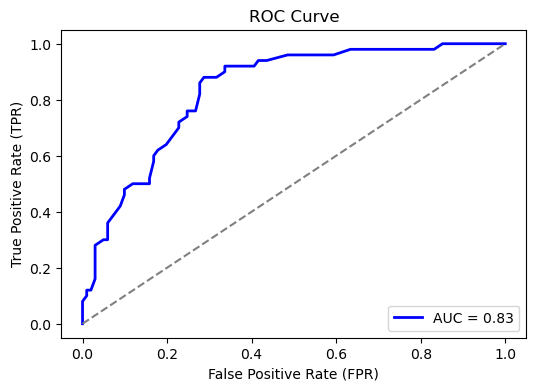


Evaluating Model for Cluster 2:
Training Accuracy: 0.99
Testing Accuracy: 0.92
No significant overfitting detected.

Confusion Matrix (Testing Data):
[[139   0]
 [ 13   1]]


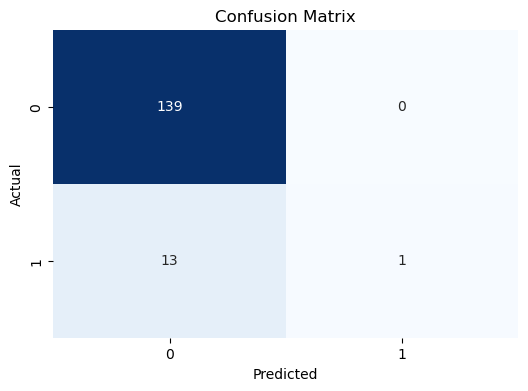

AUC-ROC Score: 0.86


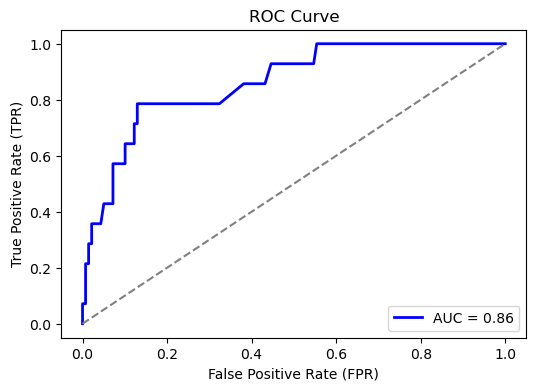


Evaluating Model for Cluster 1:
Training Accuracy: 1.00
Testing Accuracy: 0.90
No significant overfitting detected.

Confusion Matrix (Testing Data):
[[161   2]
 [ 17   6]]


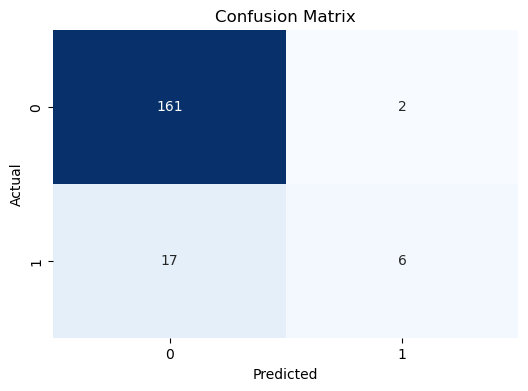

AUC-ROC Score: 0.86


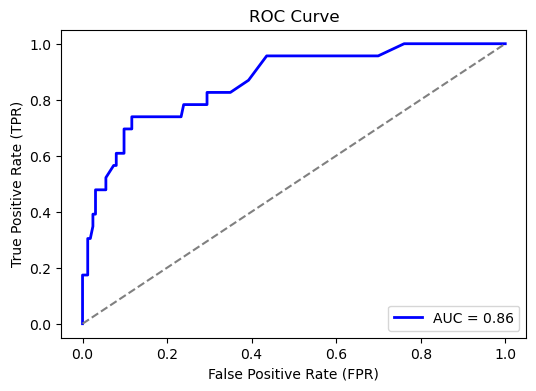


Evaluating Model for Cluster 3:
Training Accuracy: 0.99
Testing Accuracy: 0.88

Confusion Matrix (Testing Data):
[[153   5]
 [ 16   1]]


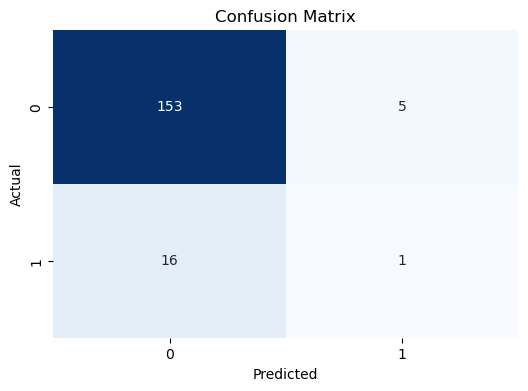

AUC-ROC Score: 0.83


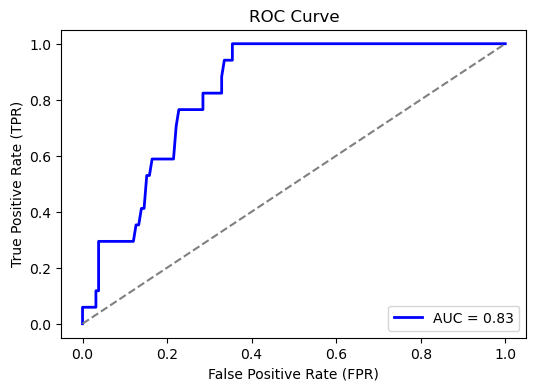

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Evaluate the model for overfitting and generate performance metrics.

    Parameters:
        model: Trained model (e.g., RandomForestClassifier).
        X_train: Training features.
        X_test: Testing features.
        y_train: Training target.
        y_test: Testing target.
    """
    # Predict on training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate accuracy for training and testing data
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"Training Accuracy: {train_accuracy:.2f}")
    print(f"Testing Accuracy: {test_accuracy:.2f}")

    # Check for overfitting
    if train_accuracy > test_accuracy + 0.1:  # Threshold for overfitting
        print("Warning: Potential overfitting detected (training accuracy significantly higher than testing accuracy).")
    else:
        print("No significant overfitting detected.")

    # Confusion Matrix
    print("\nConfusion Matrix (Testing Data):")
    conf_matrix = confusion_matrix(y_test, y_test_pred)
    print(conf_matrix)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # AUC-ROC Curve
    y_test_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    print(f"AUC-ROC Score: {roc_auc:.2f}")

    # Plot AUC-ROC Curve
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

# Example usage for each cluster
for cluster, model in models.items():
    print(f"\nEvaluating Model for Cluster {cluster}:")
    cluster_data = data[data['Segment_k4'] == cluster].reset_index(drop=True)
    X = cluster_data.drop(columns=['Response', 'Segment_k4'])
    y = cluster_data['Response']

    # One-hot encode categorical columns (if not already done)
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    if categorical_cols:
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded_features = encoder.fit_transform(X[categorical_cols])
        encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))
        X = X.drop(columns=categorical_cols)
        X = pd.concat([X, encoded_df], axis=1)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Evaluate the model
    evaluate_model(model, X_train, X_test, y_train, y_test)

## The model above doesn't perform well in each cluster, so we make some optimazations and try other models.

## RandomForest

Processing Cluster 0...
Cluster 0 - Accuracy: 0.86
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       104
           1       0.93      0.78      0.84        98

    accuracy                           0.86       202
   macro avg       0.87      0.86      0.86       202
weighted avg       0.87      0.86      0.86       202



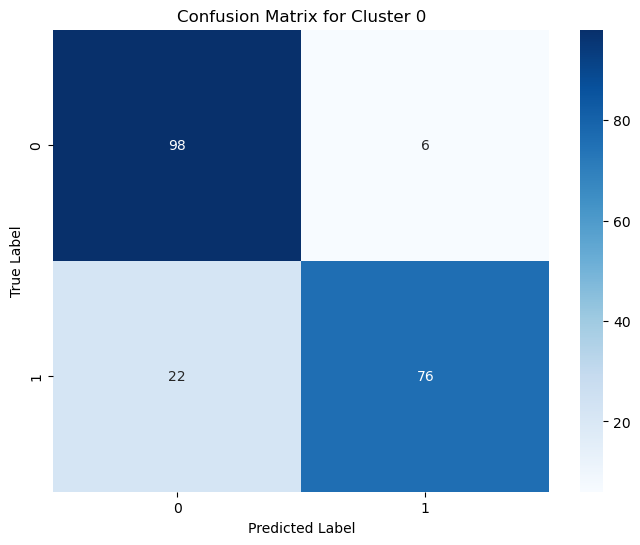

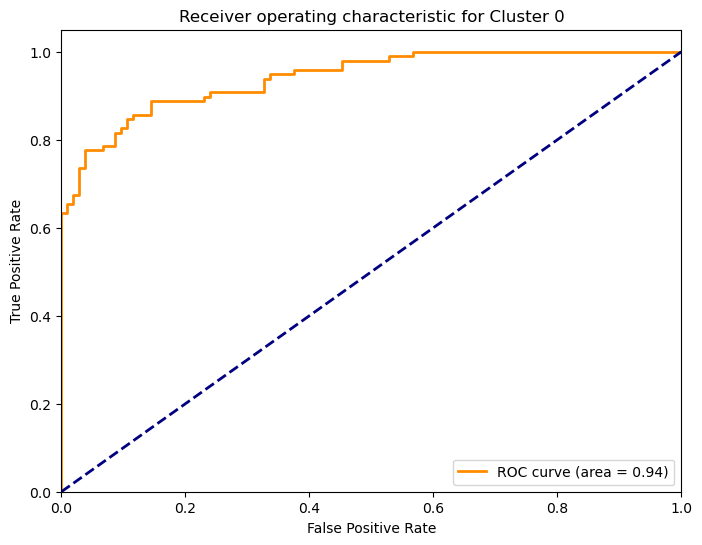

Cluster 0 - Training Accuracy: 1.00
Cluster 0 - Testing Accuracy: 0.86
Processing Cluster 2...
Cluster 2 - Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       143
           1       0.95      0.98      0.97       141

    accuracy                           0.96       284
   macro avg       0.97      0.96      0.96       284
weighted avg       0.97      0.96      0.96       284



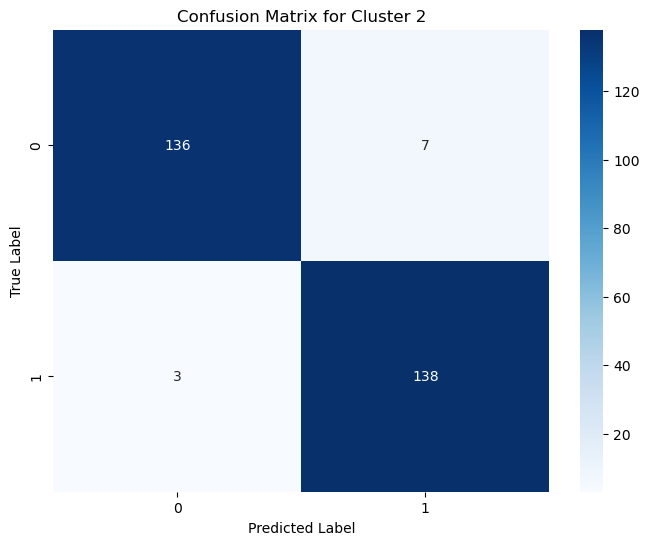

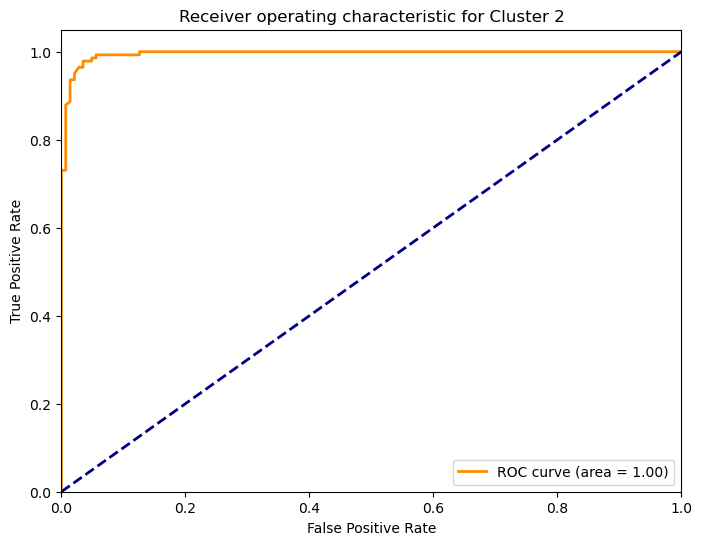

Cluster 2 - Training Accuracy: 1.00
Cluster 2 - Testing Accuracy: 0.96
No significant overfitting detected in Cluster 2.
Processing Cluster 1...
Cluster 1 - Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       177
           1       0.96      0.95      0.95       151

    accuracy                           0.96       328
   macro avg       0.96      0.96      0.96       328
weighted avg       0.96      0.96      0.96       328



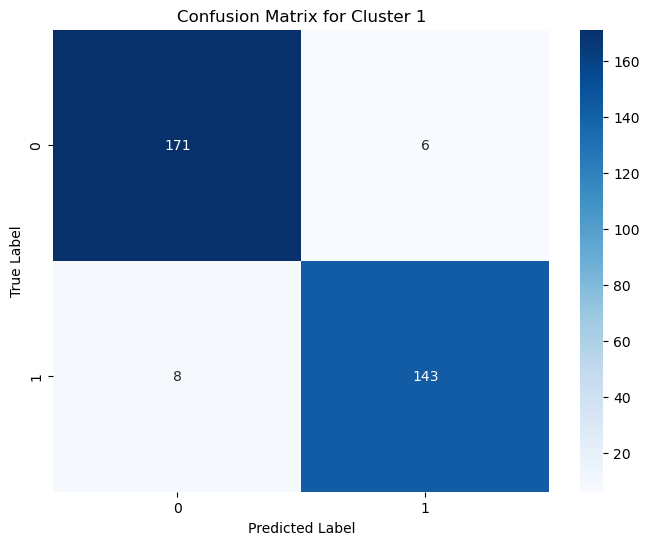

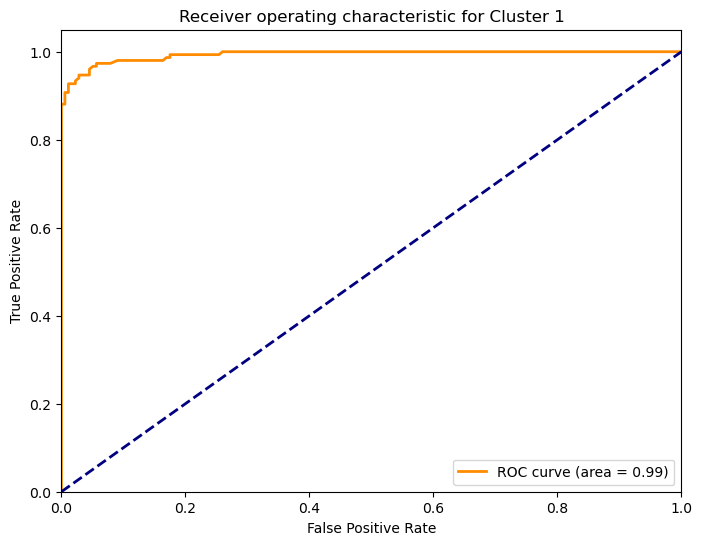

Cluster 1 - Training Accuracy: 1.00
Cluster 1 - Testing Accuracy: 0.96
No significant overfitting detected in Cluster 1.
Processing Cluster 3...
Cluster 3 - Accuracy: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       167
           1       0.94      0.91      0.92       148

    accuracy                           0.93       315
   macro avg       0.93      0.93      0.93       315
weighted avg       0.93      0.93      0.93       315



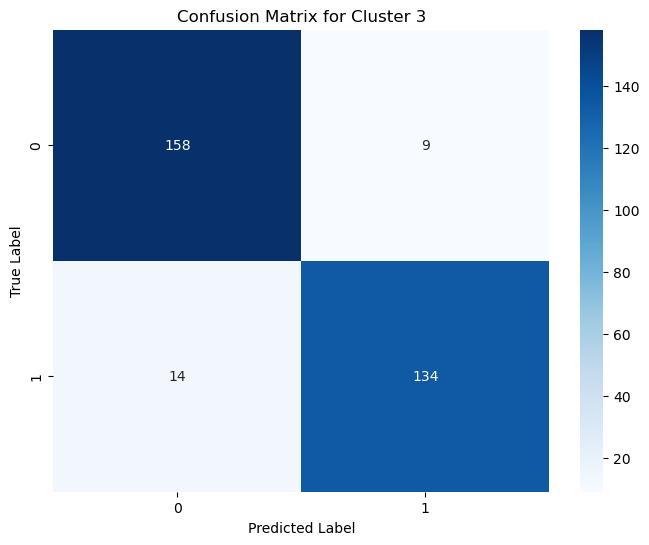

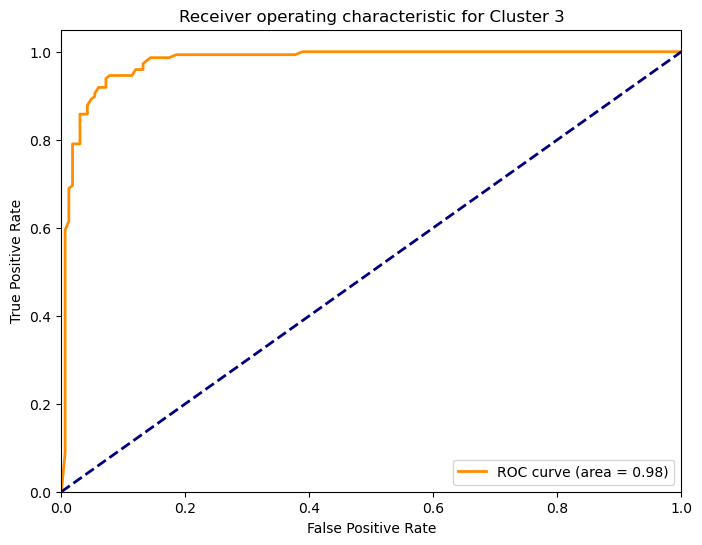

Cluster 3 - Training Accuracy: 1.00
Cluster 3 - Testing Accuracy: 0.93
No significant overfitting detected in Cluster 3.


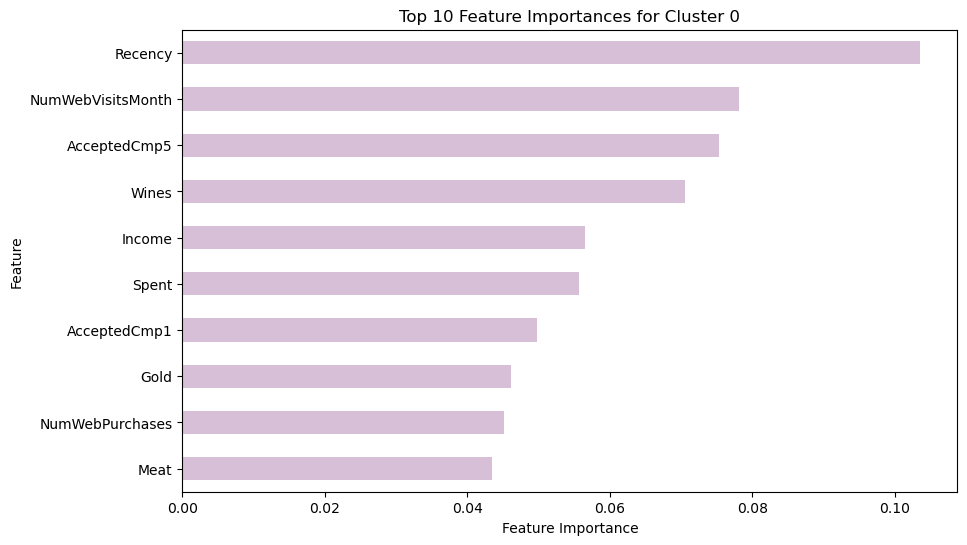

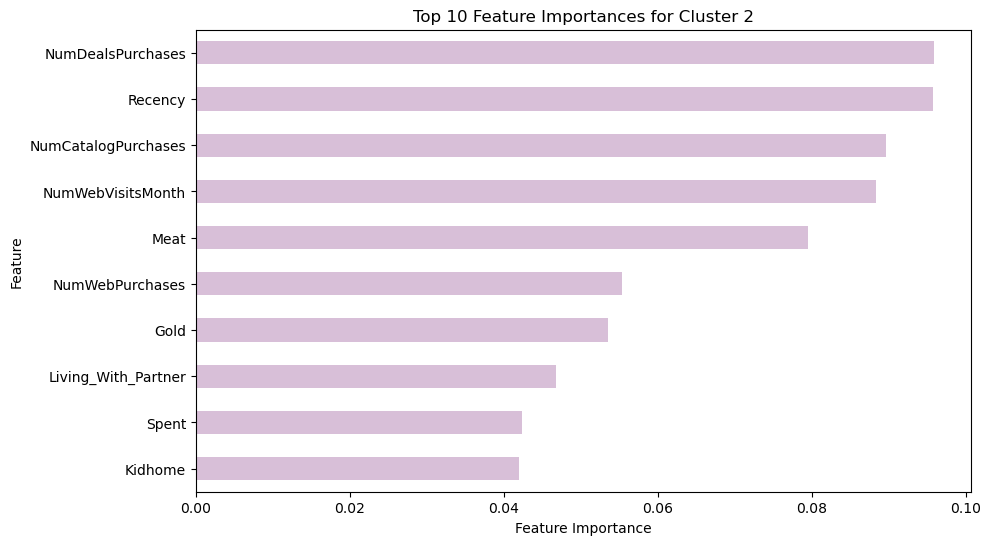

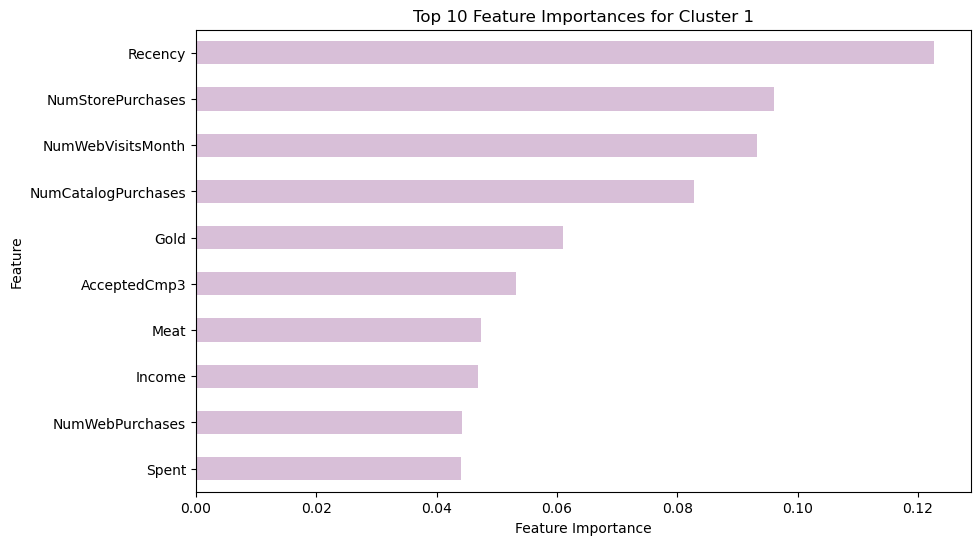

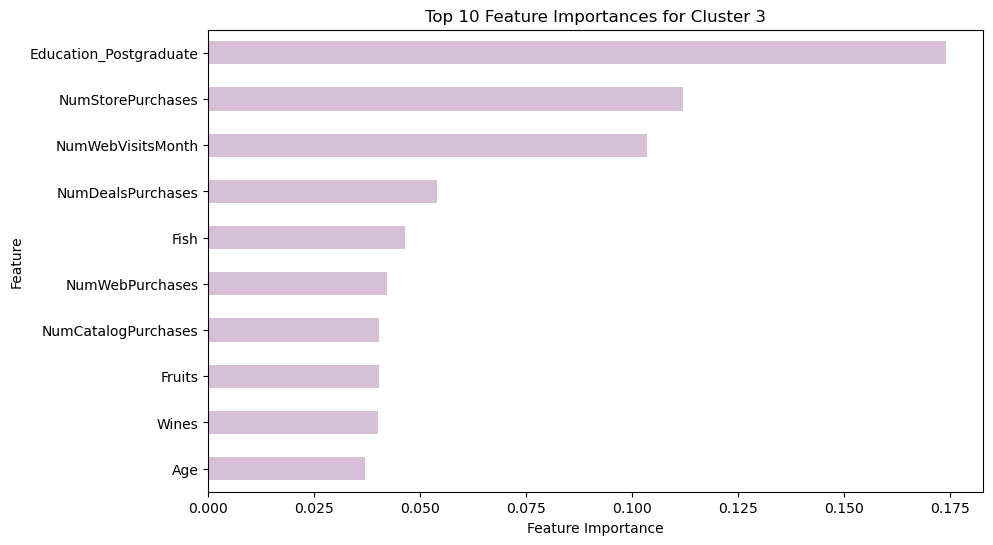

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Assume 'data' has been defined already
# Split the data by clusters
clusters = data['Segment_k4'].unique()

# Initialize dictionaries to store models and their performance
models = {}
performance = {}

# Loop through each cluster
for cluster in clusters:
    print(f"Processing Cluster {cluster}...")

    # Filter data for the current cluster and reset the index
    cluster_data = data[data['Segment_k4'] == cluster].reset_index(drop=True)

    # Separate features and target variable
    X = cluster_data.drop(columns=['Response', 'Segment_k4'])
    y = cluster_data['Response']

    # Identify categorical columns
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

    # One-hot encode categorical columns
    if categorical_cols:
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded_features = encoder.fit_transform(X[categorical_cols])
        encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

        # Drop original categorical columns and concatenate the encoded columns
        X = X.drop(columns=categorical_cols)
        X = pd.concat([X, encoded_df], axis=1)

    # Standardize numerical features
    scaler = StandardScaler()
    # Preserve column names here, convert the standardized array back to a DataFrame
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    # Handle class imbalance problem using SMOTE
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

    # Hyperparameter tuning using GridSearchCV
    param_grid = {
        'n_estimators': [50, 100, 200],
       'max_depth': [None, 10, 20, 30],
       'min_samples_split': [2, 5, 10]
    }
    model = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='f1_macro')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Make predictions on the test set
    y_pred = best_model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    # Store the model and its performance
    models[cluster] = best_model
    performance[cluster] = {
        'accuracy': accuracy,
        'classification_report': report
    }

    # Print the performance
    print(f"Cluster {cluster} - Accuracy: {accuracy:.2f}")
    print(f"Classification Report:\n{report}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for Cluster {cluster}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # AUC-ROC curve
    if len(set(y_resampled)) == 2:  # Only applicable for binary classification problems
        y_score = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver operating characteristic for Cluster {cluster}')
        plt.legend(loc="lower right")
        plt.show()

    # Overfitting check
    y_train_pred = best_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"Cluster {cluster} - Training Accuracy: {train_accuracy:.2f}")
    print(f"Cluster {cluster} - Testing Accuracy: {accuracy:.2f}")
    if abs(train_accuracy - accuracy) > 0.1:
        print(f"Warning: Possible overfitting in Cluster {cluster}!")
    else:
        print(f"No significant overfitting detected in Cluster {cluster}.")

# Plot feature importance for each cluster
for cluster, model in models.items():
    feature_importances = pd.Series(model.feature_importances_, index=X_resampled.columns)

    top_features = feature_importances.nlargest(10).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    top_features.plot(kind='barh', color='#D8BFD8')
    plt.title(f"Top 10 Feature Importances for Cluster {cluster}")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.show()

In [ ]:
for cluster, model in models.items():
    feature_importances = pd.Series(model.feature_importances_, index=X_resampled.columns)
    top_features = feature_importances.nlargest(10).sort_values(ascending=False)
    print(f"Top 10 features for Cluster {cluster}:")
    print(top_features)
    print("-" * 50)

Top 10 features for Cluster 0:
Recency              0.103595
NumWebVisitsMonth    0.078179
AcceptedCmp5         0.075358
Wines                0.070515
Income               0.056494
Spent                0.055710
AcceptedCmp1         0.049770
Gold                 0.046189
NumWebPurchases      0.045160
Meat                 0.043435
dtype: float64
--------------------------------------------------
Top 10 features for Cluster 2:
NumDealsPurchases      0.095836
Recency                0.095665
NumCatalogPurchases    0.089599
NumWebVisitsMonth      0.088264
Meat                   0.079444
NumWebPurchases        0.055277
Gold                   0.053456
Living_With_Partner    0.046697
Spent                  0.042406
Kidhome                0.041902
dtype: float64
--------------------------------------------------
Top 10 features for Cluster 1:
Recency                0.122675
NumStorePurchases      0.096059
NumWebVisitsMonth      0.093205
NumCatalogPurchases    0.082729
Gold                   0.06

## Business insights

1. **Cluster 0: Premium Shoppers**
    - **Purchase Frequency and Loyalty**: "Recency" is the most important feature, indicating that these customers may be more sensitive to recent promotions and new products. The company can regularly launch new high-end products or limited-edition items to attract their repeat purchases. Additionally, with a high "NumWebVisitsMonth", it shows that they often browse the website. Personalized recommendations of high-end products can be pushed through the website.
    - **Product Preferences**: Features such as "Wines" and "Meat" have relatively high importance, suggesting that targeted high-end food gift boxes or bundled sales can be introduced. Also, "AcceptedCmp5" is quite significant, meaning they have a certain acceptance of specific promotional activities. More attractive high-end promotional campaigns can be designed.
    - **Marketing Strategies**: Based on their high income and focus on luxury goods, continue to strengthen the VIP program by providing exclusive services like personal shopping guides and priority customer service. Launch high-end product bundles to increase the perceived value of customers' purchases and offer early access to sales to meet their demand for unique and scarce products.

2. **Cluster 1: Budget-Conscious Families**
    - **Purchase Behavior**: "Recency" is also important here, indicating that they also pay attention to recent promotions. Both "NumStorePurchases" and "NumWebVisitsMonth" are high, suggesting that they shop both offline and online to look for discounts. The company can launch discount promotions both online and offline to attract their purchases.
    - **Family Needs**: The feature of "Kidhome" implies their family-related needs. Family packages, such as combined sales of food and daily necessities, can be introduced to meet their daily family demands. Moreover, with a low "Spent", it shows that they are price-sensitive. Incentives like free shipping can reduce their shopping costs and increase their willingness to buy.
    - **Marketing Strategies**: Continuously offer discount promotions, especially for family supplies and necessities. Design family bundles to provide more product choices while reducing the unit price. Provide free shipping services to reduce their additional expenses and enhance the attractiveness of purchases.

3. **Cluster 2: Senior Deal Hunters**
    - **Purchase Habits**: "NumDealsPurchases" and "Recency" are key features, indicating that they like to buy discounted products and pay attention to recent promotions. The company should regularly launch discount activities for the elderly, especially on the essential goods they often purchase, such as "Meat".
    - **Channel Preferences**: With high "NumCatalogPurchases" and "NumWebVisitsMonth", it shows that they shop through both catalogs and online channels. Convenience in multiple shopping channels should be provided, and the online checkout process should be simplified to facilitate their shopping.
    - **Marketing Strategies**: Offer senior discounts and launch special offers on essential goods according to their needs. Simplify the checkout process to reduce the obstacles they encounter in online shopping. Promote discount information through both catalogs and online channels to ensure they can obtain it in a timely manner.

4. **Cluster 3: Omnichannel Moderate Spenders**
    - **Channel Selection**: Both "NumStorePurchases" and "NumWebVisitsMonth" are important, indicating that they prefer to flexibly choose between online and offline shopping channels. The company should provide a seamless omnichannel shopping experience, such as online purchase with in-store pickup and offline experience with online purchase.
    - **Product Interests**: "Education_Postgraduate" implies that they may have a certain consumption ability and pursuit of quality. Features like "Fish", "Fruits", and "Wines" show that they are interested in a variety of products. Personalized product recommendations can be launched, providing suitable products according to their purchase history and preferences.
    - **Marketing Strategies**: Adopt a hybrid promotion strategy, combining the advantages of online and offline channels. Provide personalized offers and recommendations, pushing product information based on their shopping history and preferences. Implement cross-channel discounts to encourage them to switch between different channels for shopping, improving the convenience and satisfaction of shopping.

## Improvement

### Deployment & Usage
- **Customer Segmentation**: Use the model to classify new customers into existing clusters. Tailor marketing strategies per segment. E.g., when a new sign-up occurs, input data to assign a cluster and guide marketing.
- **Product Recommendation**: Based on cluster feature importance, recommend relevant products. Integrate the model into the store's rec engine.
- **Pricing & Promotion**: Analyze cluster responses to pricing. Predict impacts of strategies to optimize prices and promos.

### Impact on Model Dev
- **Data & Feature Eng**: Continuously gather new data. Update/identify features to adapt to trends.
- **Model Refinement**: Regularly assess performance. Retrain/modify as needed.

### Impact on Feature Importance
- **Dynamic**: Monitor feature importance changes over time.
- **Contextual**: Consider importance in different contexts.

## SVM

Processing Cluster 0...
Cluster 0 - Accuracy: 0.90
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       104
           1       0.89      0.91      0.90        98

    accuracy                           0.90       202
   macro avg       0.90      0.90      0.90       202
weighted avg       0.90      0.90      0.90       202



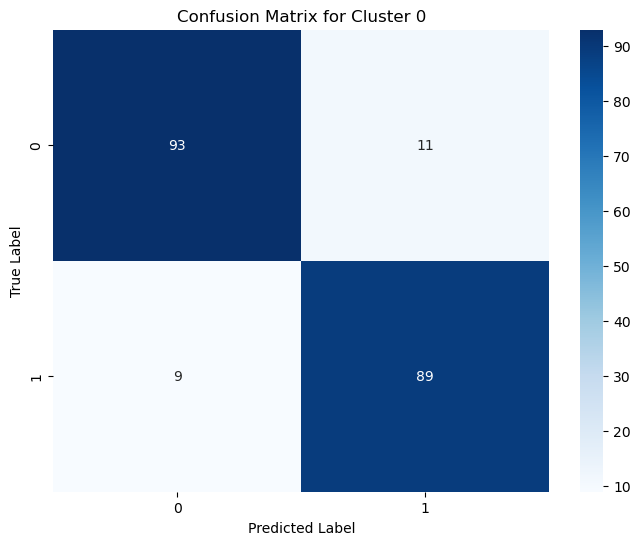

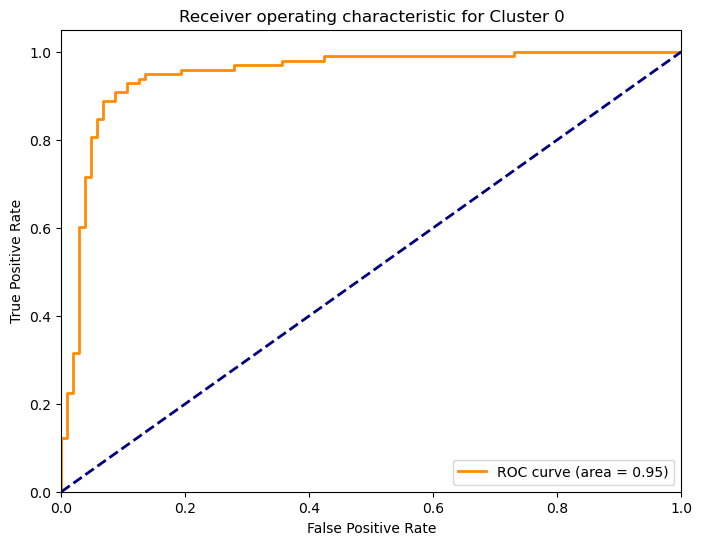

Cluster 0 - Training Accuracy: 0.99
Cluster 0 - Testing Accuracy: 0.90
No significant overfitting detected in Cluster 0.
Processing Cluster 2...
Cluster 2 - Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       143
           1       0.94      1.00      0.97       141

    accuracy                           0.97       284
   macro avg       0.97      0.97      0.97       284
weighted avg       0.97      0.97      0.97       284



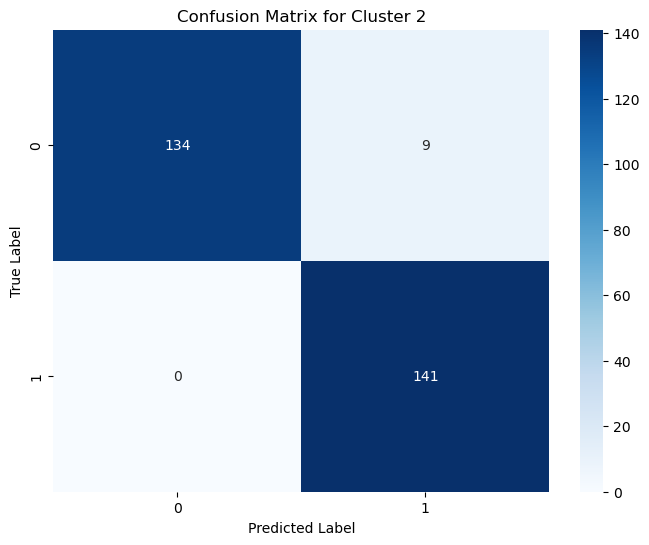

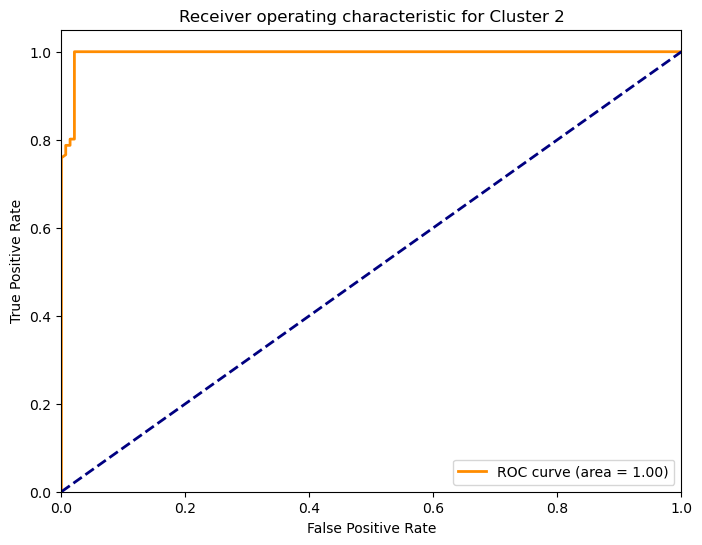

Cluster 2 - Training Accuracy: 0.99
Cluster 2 - Testing Accuracy: 0.97
No significant overfitting detected in Cluster 2.
Processing Cluster 1...
Cluster 1 - Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       177
           1       0.90      0.97      0.93       151

    accuracy                           0.94       328
   macro avg       0.94      0.94      0.94       328
weighted avg       0.94      0.94      0.94       328



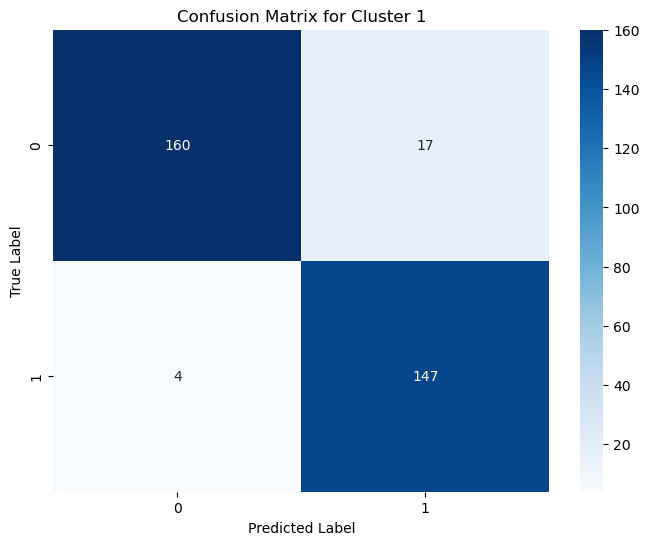

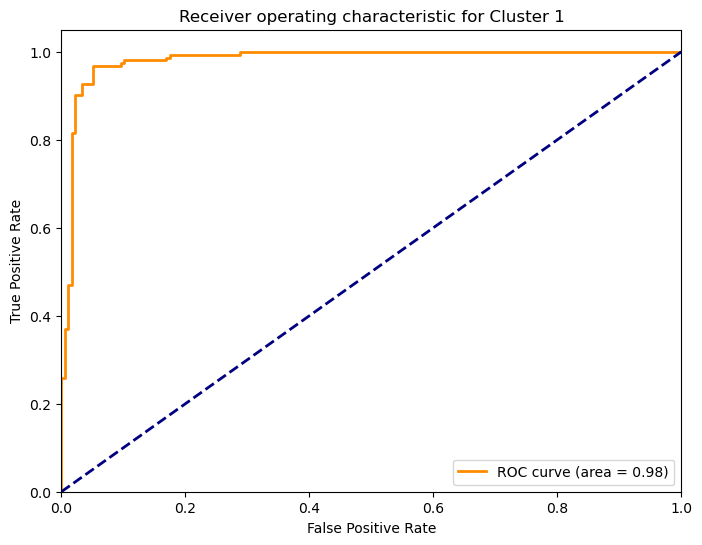

Cluster 1 - Training Accuracy: 0.98
Cluster 1 - Testing Accuracy: 0.94
No significant overfitting detected in Cluster 1.
Processing Cluster 3...
Cluster 3 - Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       167
           1       0.92      1.00      0.96       148

    accuracy                           0.96       315
   macro avg       0.96      0.96      0.96       315
weighted avg       0.96      0.96      0.96       315



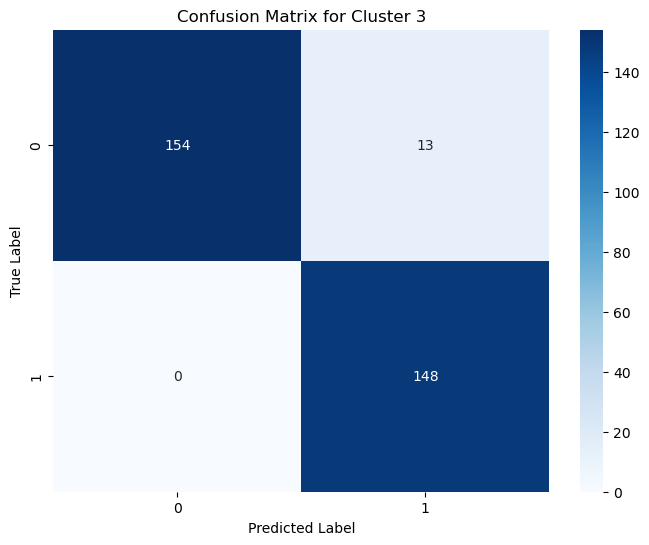

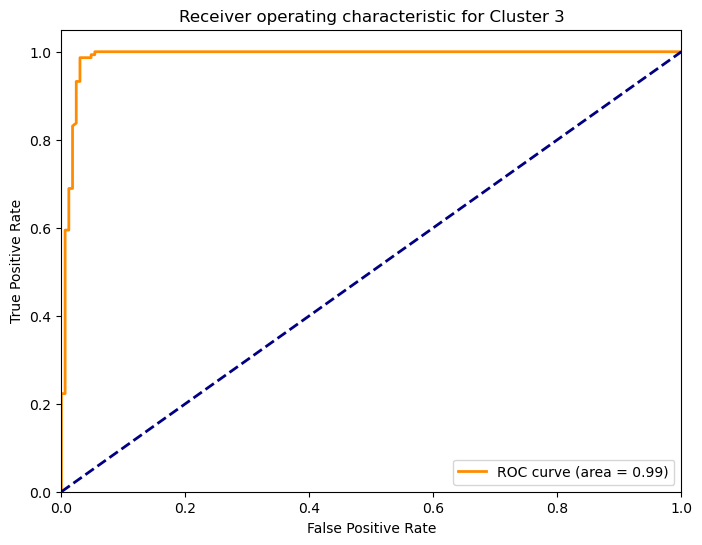

Cluster 3 - Training Accuracy: 0.99
Cluster 3 - Testing Accuracy: 0.96
No significant overfitting detected in Cluster 3.
Feature importance visualization is not available for non - linear kernel in Cluster 0.
Feature importance visualization is not available for non - linear kernel in Cluster 2.
Feature importance visualization is not available for non - linear kernel in Cluster 1.
Feature importance visualization is not available for non - linear kernel in Cluster 3.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Assume 'data' is already defined
# Split data by clusters
clusters = data['Segment_k4'].unique()

# Initialize dictionaries to store models and their performance
models = {}
performance = {}

# Loop through each cluster
for cluster in clusters:
    print(f"Processing Cluster {cluster}...")

    # Filter data for the current cluster and reset the index
    cluster_data = data[data['Segment_k4'] == cluster].reset_index(drop=True)

    # Separate features and target
    X = cluster_data.drop(columns=['Response', 'Segment_k4'])
    y = cluster_data['Response']

    # Identify categorical columns
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

    # One-hot encode categorical columns
    if categorical_cols:
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded_features = encoder.fit_transform(X[categorical_cols])
        encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

        # Drop original categorical columns and concatenate encoded columns
        X = X.drop(columns=categorical_cols)
        X = pd.concat([X, encoded_df], axis=1)

    # Standardize numerical features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    # Handle class imbalance using SMOTE
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

    # Hyperparameter tuning using GridSearchCV
    param_grid = {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
    model = SVC(random_state=42, probability=True)
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='f1_macro')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Make predictions on the test set
    y_pred = best_model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    # Store the model and its performance
    models[cluster] = best_model
    performance[cluster] = {
        'accuracy': accuracy,
        'classification_report': report
    }

    # Print the performance
    print(f"Cluster {cluster} - Accuracy: {accuracy:.2f}")
    print(f"Classification Report:\n{report}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for Cluster {cluster}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # AUC - ROC curve
    if len(set(y_resampled)) == 2:  # Only applicable for binary classification
        y_score = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver operating characteristic for Cluster {cluster}')
        plt.legend(loc="lower right")
        plt.show()

    # Overfitting check
    y_train_pred = best_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"Cluster {cluster} - Training Accuracy: {train_accuracy:.2f}")
    print(f"Cluster {cluster} - Testing Accuracy: {accuracy:.2f}")
    if abs(train_accuracy - accuracy) > 0.1:
        print(f"Warning: Possible overfitting in Cluster {cluster}!")
    else:
        print(f"No significant overfitting detected in Cluster {cluster}.")

# Since SVM doesn't have a feature_importances_ attribute, we can approximate feature importance
# by the coefficients of a linear kernel (only applicable for linear kernels)
for cluster, model in models.items():
    if model.kernel == 'linear':
        # Retrieve the coefficients of the linear SVM model
        coefficients = model.coef_[0]
        # Create a Pandas Series to associate coefficients with feature names
        feature_importances = pd.Series(coefficients, index=X_resampled.columns)
        # Take the absolute value of the coefficients to get the magnitude of importance
        feature_importances = feature_importances.abs()
        # Select the top 10 most important features
        top_features = feature_importances.nlargest(10).sort_values(ascending=True)

        plt.figure(figsize=(10, 6))
        top_features.plot(kind='barh', color='#D8BFD8')
        plt.title(f"Top 10 Feature Importances for Cluster {cluster}")
        plt.xlabel("Feature Importance (Linear SVM Coefficient Magnitude)")
        plt.ylabel("Feature")
        plt.show()
    else:
        print(f"Feature importance visualization is not available for non - linear kernel in Cluster {cluster}.")